# Estruturas de Dados para Processamento de Linguagem Natural
## Skip-gram e busca semântica sobre discursos parlamentares brasileiros

**Disciplina:** Estruturas para Ciência de Dados — Graduação em Data Science e Machine Learning, CEUB

**Autores:** 
- Erick Cardoso Mendes, RA: 22509170
- Lanna Correa Soares, RA: 22505387

**Corpus:** ~8.000 discursos da 57ª legislatura da Câmara dos Deputados (jan/2024 – jun/2026)

---

### Sobre este notebook

Este notebook implementa, **do zero** (sem PyTorch, TensorFlow, JAX, Gensim ou
bibliotecas prontas), um pipeline completo de embeddings
distribucionais — Word2Vec/Skip-gram com *hierarchical softmax* — e de busca
semântica aproximada. O objetivo formal é cumprir a rubrica da disciplina, que
exige o uso **integrado e justificado** de pelo menos quatro estruturas de dados
clássicas. O princípio orientador é que cada estrutura seja introduzida porque a
**matemática do problema a exige**, não porque a rubrica a permite:

| Estrutura | Papel | Complexidade-chave |
|---|---|---|
| **Dicionário** (hash table) | Vocabulário: `token → id`, frequências, prob. de subsampling | Acesso $O(1)$ médio |
| **Heap → Árvore de Huffman** | *Hierarchical softmax* (código de prefixo ótimo) | Treino $O(\log V)$ |
| **Pilha** | Grafo computacional do *autograd* (backpropagation) | *Backward* $O(n)$ |
| **Grafo** (HNSW) | Índice de vizinhos mais próximos aproximados | Busca $O(\log N)$ |

> **Organização.** O notebook é desenvolvido camada por camada; cada etapa é
> uma unidade coesa com entradas, saídas e *sanity checks* visíveis. As quatro
> estruturas aparecem na ordem em que a construção do método as exige.

### Mapa das seções

- **§0** — Cabeçalho (esta seção)
- **§1** — Fundamentação teórica
- **§2** — Setup: imports, *seeds*, constantes globais
- **§3** — Carregamento do corpus pré-coletado
- **§4** — Vocabulário e subsampling — *dicionário* (hash table)
- **§5** — Árvore de Huffman e *hierarchical softmax* — *heap → árvore binária*
- **§6** — Mini-autograd — *pilha* (LIFO)
- **§7** — Modelo Skip-gram com *hierarchical softmax*
- **§8** — Loop de treino (SGD)
- **§9** — Inspeção qualitativa dos embeddings (vizinhos + t-SNE)
- **§10** — Indexação semântica — *grafo* (HNSW)
- **§11** — Busca semântica top-K — *min-heap*
- **§12** — Síntese: mapeamento das quatro estruturas
- **§13** — Limitações e trabalhos futuros
- **§14** — Referências


## §1 — Fundamentação teórica

### 1.1 Por que embeddings distribucionais

A representação mais ingênua de uma palavra em um vocabulário de tamanho $V$ é o
vetor *one-hot*: um vetor em $\{0,1\}^V$ com um único 1 na posição do índice da
palavra. Essa representação tem dois defeitos fatais para qualquer tarefa
semântica. Primeiro, é **ortogonal por construção**: o produto interno entre
quaisquer duas palavras distintas é zero, de modo que *"imposto"* e *"tributo"*
são tão distantes entre si quanto *"imposto"* e *"girassol"*. A representação não
carrega nenhuma noção de similaridade. Segundo, é **catastroficamente esparsa e
de alta dimensão**: com $V \approx 30\text{–}80\text{k}$, cada palavra vive em um
espaço de dezenas de milhares de dimensões, inviabilizando generalização
estatística.

Os **embeddings distribucionais** atacam ambos os problemas ao mapear cada
palavra para um vetor **denso** em $\mathbb{R}^D$, com $D \ll V$ (aqui $D = 100$).
O fundamento teórico é a **hipótese distribucional** (Harris, 1954; Firth, 1957):
*"você conhece uma palavra pela companhia que ela mantém"* — palavras que
ocorrem em contextos semelhantes tendem a ter significados semelhantes. Se o
treino força palavras de contextos parecidos a ocupar regiões próximas de
$\mathbb{R}^D$, a **similaridade do cosseno** entre vetores passa a aproximar
similaridade semântica, e operações algébricas no espaço vetorial passam a
capturar relações de analogia.

O **Skip-gram** (Mikolov et al., 2013a) operacionaliza essa hipótese como um
problema preditivo: dada uma palavra-centro, o modelo aprende a prever as
palavras de seu **contexto** dentro de uma janela. Os pesos da camada de entrada,
ao final do treino, *são* os embeddings. A elegância do método — e a razão de ele
ser o objeto de estudo deste trabalho — está em seus três truques fundamentais
(*hierarchical softmax*, *subsampling* de palavras frequentes e *negative
sampling*), que, sob a ótica da teoria da informação, são todos formas de
**manipulação controlada de entropia ou de injeção de ruído estatístico**.

Vale registrar que essa formulação preditiva não é um truque isolado: Levy &
Goldberg (2014) mostram que o Skip-gram com *negative sampling* fatoriza
implicitamente uma matriz de informação mútua pontual (PMI) deslocada entre
palavras e contextos — ou seja, o método tem uma interpretação algébrica precisa
em termos de coocorrência, o que reforça sua legitimidade teórica.

> *A subseção 1.4 (o papel do ruído: subsampling e a distribuição $\tfrac{3}{4}$)
> será desenvolvida junto às Etapas 4–6, quando as estruturas correspondentes
> forem implementadas.*

### 1.2 Skip-gram: o objetivo e o gargalo do softmax

Dado um corpus como uma sequência de palavras $w_1, w_2, \dots, w_T$, o Skip-gram
maximiza a log-verossimilhança média de prever as palavras de contexto a partir
de cada palavra-centro:

$$ \mathcal{J} = \frac{1}{T} \sum_{t=1}^{T} \sum_{-c \le j \le c,\; j \ne 0}
\log p(w_{t+j} \mid w_t). $$

A formulação canônica modela $p(o \mid c)$ — a probabilidade de uma palavra de
saída $o$ dada a palavra-centro $c$ — por um **softmax** sobre todo o
vocabulário, usando o embedding de entrada $v_c$ e um vetor de saída $u_w$ por
palavra:

$$ p(o \mid c) = \frac{\exp\!\big(u_o^\top v_c\big)}
{\sum_{w=1}^{V} \exp\!\big(u_w^\top v_c\big)}. $$

O problema é o **denominador**: ele soma sobre as $V$ palavras do vocabulário, de
modo que cada avaliação — e cada gradiente — custa $O(V)$. Com
$N \approx 4\text{M}$ tokens, várias palavras de contexto por token e múltiplas
épocas, o custo total $O(N \cdot V)$ é proibitivo. As duas saídas clássicas
(Mikolov, 2013b) são o *negative sampling* e o **hierarchical softmax** — este
último, o protagonista da Etapa 3 e o que motiva a árvore de Huffman.

### 1.3 Hierarchical softmax e codificação de Huffman

O **hierarchical softmax** (Morin & Bengio, 2005; Mikolov et al., 2013b)
substitui o softmax plano de $V$ resultados por uma sequência de **decisões
binárias** ao longo de um caminho em uma **árvore binária cujas folhas são as
palavras**. Cada um dos $V-1$ nós internos $n$ carrega seu próprio vetor de
parâmetros $\theta_n \in \mathbb{R}^D$. A probabilidade de uma palavra $w$ é o
produto das probabilidades das ramificações de seu caminho da raiz até a folha:

$$ p(w \mid c) = \prod_{j=1}^{L(w)-1}
\sigma\!\Big( \llbracket b_j \rrbracket \cdot \theta_{n_j}^\top v_c \Big),
\qquad
\llbracket b_j \rrbracket = \begin{cases} +1 & \text{se } b_j = 0 \\ -1 & \text{se } b_j = 1, \end{cases} $$

onde $b_j$ é o bit (0 = esquerda, 1 = direita) do código de $w$ no nó $n_j$, e
$\sigma$ é a sigmoide. Essa fatoração é uma distribuição de probabilidade válida
(a soma sobre todas as folhas é 1, por construção), e seu custo por palavra é
$O\big(L(w)\big)$ — o **comprimento do caminho** —, não mais $O(V)$. Para uma
árvore balanceada isso já seria $O(\log V)$.

**Por que Huffman, e não uma árvore balanceada qualquer?** Porque podemos fazer
melhor que $\log V$ *na média*. A escolha da topologia da árvore é livre, e o
custo esperado de uma atualização é o **comprimento médio de caminho ponderado
pela frequência**:

$$ L = \sum_{w} p(w)\, L(w), \qquad p(w) = \frac{\text{freq}(w)}{N}. $$

Minimizar $L$ é exatamente o problema que a **árvore de Huffman** (Huffman, 1952)
resolve de forma ótima: ela é o **código de prefixo de menor comprimento médio**
para uma distribuição de probabilidades dada. Atribuir caminhos curtos às
palavras frequentes (que são consultadas com mais frequência no treino) e
caminhos longos às raras minimiza o número esperado de avaliações de sigmoide por
atualização.

**A amarração com a teoria da informação.** O teorema de codificação de fonte de
Shannon (1948) garante que o comprimento médio de *qualquer* código de prefixo é
limitado inferiormente pela **entropia** da fonte, e Huffman atinge esse limite a
menos de um bit:

$$ H(W) \;\le\; L \;<\; H(W) + 1,
\qquad H(W) = -\sum_{w} p(w) \log_2 p(w). $$

Ou seja, a mesma estrutura que minimiza os *bits* para codificar a fonte minimiza
o *trabalho computacional* do softmax — e o custo esperado do hierarchical
softmax fica da ordem de $H(W)$, tipicamente bem abaixo de $\log_2 V$. A
**Etapa 3** valida empiricamente essa desigualdade (§5.3), conectando diretamente uma estrutura de dados
clássica a um teorema de teoria da informação.

## §2 — Setup: imports, *seeds* e constantes globais

Centralizamos aqui todas as dependências, a fixação de *seeds* para
reprodutibilidade e as constantes globais —
em especial os **hiperparâmetros** do Skip-gram, justificados em Mikolov (2013a,
2013b). Mantê-los em um único bloco evita números mágicos espalhados pelo código
e facilita a calibração futura.

In [6]:
"""§2 — Setup global do notebook.

Imports, fixação de seeds e constantes. Nenhuma biblioteca de embeddings ou
de deep learning é importada: o ponto pedagógico do trabalho é reimplementar
tudo apenas com NumPy e matemática.
"""
from __future__ import annotations

import logging
import math
import pickle
import random
import re
import sys
from collections import Counter
from collections.abc import Iterable
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------- Logging básico
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
)
logger = logging.getLogger("notebook")

# ----------------------------------------------------- Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------- Caminhos
DATA_DIR = Path("data")
ARTEFATOS_DIR = Path("artefatos")
ARTEFATOS_DIR.mkdir(exist_ok=True)

PARQUET_PATH = DATA_DIR / "discursos.parquet"
METADATA_PATH = DATA_DIR / "discursos_metadata.json"
VOCAB_PATH = ARTEFATOS_DIR / "vocab.pkl"

# ------------------------------------------ Hiperparâmetros base da indústria para esse tipo de conjunto de dados (Mikolov 2013a/b)
EMBEDDING_DIM = 100      # D — sweet spot para um vocabulário de 23,5k em corpus de domínio
WINDOW = 5               # c — janela de contexto
MIN_COUNT = 5            # descarta tokens com < 5 ocorrências (para varrer erros e nomes raros)
SUBSAMPLE_T = 1e-5       # t — threshold de subsampling de palavras frequentes
NEG_POWER = 0.75         # expoente da distribuição de unigrama p/ negative sampling
EPOCHS = 5               # nº de épocas de treino
LR_START = 0.025         # learning rate inicial
LR_END = 1e-4            # learning rate final (decaimento linear)

# ------------------------------------------------------ Estilo dos gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 5)

logger.info("Setup concluído.")
logger.info("Versões: numpy=%s | pandas=%s", np.__version__, pd.__version__)
logger.info(
    "Hiperparâmetros: D=%d, c=%d, min_count=%d, t=%.0e, neg_power=%.2f",
    EMBEDDING_DIM, WINDOW, MIN_COUNT, SUBSAMPLE_T, NEG_POWER,
)


19:24:29 [INFO] Setup concluído.
19:24:29 [INFO] Versões: numpy=2.4.6 | pandas=3.0.3
19:24:29 [INFO] Hiperparâmetros: D=100, c=5, min_count=5, t=1e-05, neg_power=0.75


## §3 — Carregamento do corpus pré-coletado

O corpus foi coletado e amostrado pelo script `coleta_corpus.py` (Etapa 1), que é
o **contrato de reprodução**: dada a mesma *seed* e o mesmo período, qualquer
pessoa obtém o mesmo corpus. Aqui apenas o carregamos e validamos. O schema do
parquet contém somente dados públicos da API de Dados Abertos da Câmara.

**Tratamento de duplicatas.** O diagnóstico do corpus identificou três
`id_discurso` repetidos — duplicações técnicas acidentais (o mesmo discurso
ingerido duas vezes). Removemos essas três linhas, mantendo a primeira
ocorrência. As ~87 transcrições idênticas com *ids distintos* (discursos
encaminhados co-assinados ou registrados por parlamentar que mudou de nome) são
legítimas e **preservadas**.

In [7]:
def carregar_corpus(
    parquet_path: Path = PARQUET_PATH,
    metadata_path: Path = METADATA_PATH,
) -> tuple[pd.DataFrame, dict]:
    """Carrega o corpus pré-coletado e o metadata descritivo.

    Remove duplicações técnicas (ids repetidos) preservando a primeira
    ocorrência, e ordena por data para tornar o carregamento determinístico.

    Parâmetros
    ----------
    parquet_path : Path
        Caminho do parquet gerado por `coleta_corpus.py`.
    metadata_path : Path
        Caminho do JSON de estatísticas descritivas.

    Retorna
    -------
    tuple[pd.DataFrame, dict]
        DataFrame do corpus (deduplicado) e dicionário de metadata.
    """
    import json

    df = pd.read_parquet(parquet_path)
    with open(metadata_path, encoding="utf-8") as f:
        metadata = json.load(f)

    n_antes = len(df)
    df = df.drop_duplicates(subset="id_discurso", keep="first").reset_index(drop=True)
    n_removidos = n_antes - len(df)
    if n_removidos:
        logger.info("Removidas %d linha(s) com id_discurso duplicado.", n_removidos)

    df = df.sort_values(["data", "id_deputado"]).reset_index(drop=True)
    logger.info("Corpus carregado: %d discursos, %d colunas.", *df.shape)
    return df, metadata


corpus, metadata = carregar_corpus()

19:24:29 [INFO] Removidas 3 linha(s) com id_discurso duplicado.
19:24:29 [INFO] Corpus carregado: 7997 discursos, 10 colunas.


### 3.1 *Sanity checks* do corpus

Confirmamos o schema, inspecionamos as primeiras linhas e validamos a
distribuição de tamanhos das transcrições — a matéria-prima que alimentará o
vocabulário.

In [8]:
# Schema e amostra (sem a transcrição completa, para não poluir a saída)
print("Shape:", corpus.shape)
print("\nColunas e tipos:")
print(corpus.dtypes.to_string())

cols_meta = [c for c in corpus.columns if c not in ("transcricao", "sumario")]
print("\nPrimeiras linhas (metadados):")
display(corpus[cols_meta].head(5))

Shape: (7997, 10)

Colunas e tipos:
id_discurso        str
id_deputado      int64
nome_deputado      str
sigla_partido      str
sigla_uf           str
data               str
tipo_discurso      str
fase_evento        str
transcricao        str
sumario            str

Primeiras linhas (metadados):


,id_discurso,id_deputado,nome_deputado,sigla_partido,sigla_uf,data,tipo_discurso,fase_evento
0,74057-e961075dd1,74057,Alice Portugal,PCdoB,BA,2024-02-06,BREVES COMUNICAÇÕES,Breves Comunicações
1,141555-04f1fd05e2,141555,Vinicius Carvalho,PL,SP,2024-02-06,DISCURSO ENCAMINHADO,Encerramento
2,156190-bd64b20114,156190,Marcel van Hattem,NOVO,RS,2024-02-06,BREVES COMUNICAÇÕES,Breves Comunicações
3,160535-017646ac84,160535,Marcon,PT,RS,2024-02-06,BREVES COMUNICAÇÕES,Breves Comunicações
4,160610-b6d6cf107a,160610,Valmir Assunção,PT,BA,2024-02-06,BREVES COMUNICAÇÕES,Breves Comunicações


In [9]:
# Distribuição de tamanhos (caracteres e tokens whitespace) e composição
n_chars = corpus["transcricao"].str.len()
n_tokens_ws = corpus["transcricao"].str.split().map(len)

resumo = pd.DataFrame({
    "caracteres": n_chars.describe(percentiles=[.05, .5, .95, .99]),
    "tokens_whitespace": n_tokens_ws.describe(percentiles=[.05, .5, .95, .99]),
})
print("Distribuição de tamanhos das transcrições:")
display(resumo.round(1))

print(f"\nTotal de tokens whitespace no corpus: {n_tokens_ws.sum():,}")
print(f"Período: {corpus['data'].min()} a {corpus['data'].max()}")
print(f"Deputados: {corpus['id_deputado'].nunique()} | "
      f"Partidos: {corpus['sigla_partido'].nunique()} | "
      f"UFs: {corpus['sigla_uf'].nunique()}")

print("\nDistribuição por tipo de discurso (top 8):")
print(corpus["tipo_discurso"].value_counts().head(8).to_string())

Distribuição de tamanhos das transcrições:


,caracteres,tokens_whitespace
count,7997.0,7997.0
mean,3049.7,499.9
std,2166.7,340.8
min,165.0,27.0
5%,861.0,143.0
50%,2582.0,427.0
95%,6590.0,1080.4
99%,11009.4,1740.8
max,43283.0,6782.0



Total de tokens whitespace no corpus: 3,998,017
Período: 2024-02-06 a 2026-06-10
Deputados: 559 | Partidos: 22 | UFs: 27

Distribuição por tipo de discurso (top 8):
tipo_discurso
BREVES COMUNICAÇÕES                                  3971
DISCUSSÃO                                            1056
DISCURSO ENCAMINHADO                                  895
COMO LÍDER                                            753
ENCAMINHAMENTO DE VOTAÇÃO                             613
PARECER                                               335
FALA DO PRESIDENTE OU NO EXERCÍCIO DA PRESIDÊNCIA     142
HOMENAGEM                                             119


## §4 — Classe `Vocab`: construção, subsampling e *sanity checks*

> **Estrutura protagonista: dicionário (hash table).**

### 4.1 Tokenização

A tokenização é deliberadamente **crua**: *lowercase*, remoção de pontuação e
*split* por espaço em branco. **Sem stemming e sem lematização** — queremos que
os próprios embeddings aprendam a morfologia (que *"imposto"*, *"impostos"* e
*"tributação"* são relacionados que emergem do treino, não de um pré-processamento
que o imponha). Mantemos letras acentuadas (essenciais em português) e dígitos;
descartamos apenas pontuação e símbolos.

In [10]:
# Expressão regular de tokenização: sequências de letras (com acentos) e dígitos.
# Tudo o que não casa (pontuação, símbolos) atua como separador.
_TOKEN_RE = re.compile(r"[0-9a-záàâãéèêíïóôõöúüçñ]+")


def tokenizar(texto: str) -> list[str]:
    """Tokeniza um texto: lowercase + remoção de pontuação + split.

    Sem stemming nem lematização — a morfologia deve emergir dos embeddings.

    Parâmetros
    ----------
    texto : str
        Texto bruto da transcrição.

    Retorna
    -------
    list[str]
        Lista de tokens em caixa baixa.
    """
    return _TOKEN_RE.findall(texto.lower())


# Sanity check da tokenização em um trecho real
_exemplo = corpus["transcricao"].iloc[0][:160]
print("Trecho bruto:\n", _exemplo)
print("\nTokens:\n", tokenizar(_exemplo)[:30])


Trecho bruto:
 A SRA. ALICE PORTUGAL (Bloco/PCdoB - BA. Sem revisão da oradora.) - Deputado Gilberto Nascimento, Srs. Deputados, Sras. Deputadas, primeiro, quero desejar que t

Tokens:
 ['a', 'sra', 'alice', 'portugal', 'bloco', 'pcdob', 'ba', 'sem', 'revisão', 'da', 'oradora', 'deputado', 'gilberto', 'nascimento', 'srs', 'deputados', 'sras', 'deputadas', 'primeiro', 'quero', 'desejar', 'que', 't']


In [11]:
# Tokeniza todo o corpus uma única vez (reusado na construção do vocab e no treino).
logger.info("Tokenizando o corpus...")
corpus_tokenizado: list[list[str]] = [tokenizar(t) for t in corpus["transcricao"]]
_n_tokens = sum(len(toks) for toks in corpus_tokenizado)
logger.info(
    "Tokenização concluída: %d documentos, %d tokens (pré-filtro).",
    len(corpus_tokenizado), _n_tokens,
)


19:24:30 [INFO] Tokenizando o corpus...
19:24:31 [INFO] Tokenização concluída: 7997 documentos, 4013998 tokens (pré-filtro).


### 4.2 A classe `Vocab` e a justificativa do dicionário

A estrutura central da Etapa 2 é o **dicionário (hash table)**. A escolha não é
de conveniência — é a única estrutura que sustenta a complexidade-alvo do treino.

**Dado armazenado.** Mapeamento bidirecional `token → id` (via `dict`) e
`id → token` (via `list`, que é um dicionário denso de inteiros contíguos), além
de frequências absolutas, probabilidades de *keep* pós-*subsampling* e a
distribuição de unigrama elevada a $0{,}75$ para o *negative sampling* futuro.

**Justificativa de complexidade.** Durante o treino do Skip-gram, a cada token de
cada janela de contexto consultam-se ID, frequência e probabilidade de descarte.
Com vocabulário $V \approx 30\text{–}80\text{k}$ e total de tokens
$N \approx 4\text{M}$, uma busca linear em lista — $O(V)$ por consulta — tornaria
o treino inviável (seriam $O(N \cdot V)$ operações só de *lookup*). A hash table
oferece acesso médio $O(1)$, reduzindo o custo total de *lookup* a $O(N)$. A
construção do vocabulário é $O(N)$ (uma passada contando com `Counter`, também
uma hash table) e ocorre **uma única vez**.

**Subsampling de palavras frequentes (Mikolov, 2013b).** Cada token é *mantido*
com probabilidade

$$ P_{\text{keep}}(w) = \sqrt{\dfrac{t}{f(w)}}, \qquad f(w) = \dfrac{\text{freq}(w)}{N}, $$

(*clipada* em $1{,}0$), onde $t = 10^{-5}$ é o *threshold*. Palavras raras, com
$f(w) \le t$ (equivalentemente $\text{freq}(w) \le t \cdot N$), recebem
$P_{\text{keep}} = 1{,}0$ e nunca são descartadas; palavras muito frequentes
(*stopwords*, jargão procedimental) são descartadas com alta probabilidade. O
efeito é duplo: reduz-se o peso de tokens semanticamente vazios e **expande-se a
janela efetiva de contexto** (ao remover *stopwords*, palavras de conteúdo antes
distantes passam a co-ocorrer). Esta é uma das três formas de *ruído controlado*
que estruturam o método.


In [12]:
@dataclass
class Vocab:
    """Vocabulário do corpus:

    Combina três visões complementares, todas com acesso O(1):
      - `token2id`: hash table str -> int (lookup de ID no treino);
      - `id2token`: list int -> str (dicionário denso de inteiros contíguos);
      - estatísticas indexadas por ID (`freq`, `prob_keep`, `unigram_pow_075`).

    Os IDs são atribuídos por frequência decrescente (ID 0 = token mais
    frequente), o que torna o *rank* de Zipf igual a `id + 1` e simplifica os
    sanity checks.

    Atributos
    ---------
    token2id : dict[str, int]
        Mapa token -> ID. Acesso O(1) médio.
    id2token : list[str]
        Mapa ID -> token (lista densa indexada por inteiro).
    freq : dict[int, int]
        Frequências absolutas por ID.
    prob_keep : dict[int, float]
        Probabilidade de MANTER o token no subsampling, sqrt(t/f) clipada em 1.
    unigram_pow_075 : np.ndarray
        Distribuição de unigrama^0.75 normalizada (negative sampling futuro).
    total_tokens : int
        Total de tokens dentro do vocabulário (pós min_count).
    min_count : int
        Limiar de frequência mínima aplicado.
    subsample_t : float
        Threshold t do subsampling.
    """

    token2id: dict[str, int]
    id2token: list[str]
    freq: dict[int, int]
    prob_keep: dict[int, float]
    unigram_pow_075: np.ndarray
    total_tokens: int
    min_count: int
    subsample_t: float

    def __len__(self) -> int:
        return len(self.id2token)

    def __contains__(self, token: str) -> bool:
        return token in self.token2id

    def freq_de(self, token: str) -> int:
        """Frequência absoluta de um token (0 se fora do vocabulário)."""
        idx = self.token2id.get(token)
        return self.freq[idx] if idx is not None else 0

    @classmethod
    def build(
        cls,
        corpus_tokens: Iterable[list[str]],
        min_count: int = MIN_COUNT,
        subsample_t: float = SUBSAMPLE_T,
        neg_power: float = NEG_POWER,
    ) -> "Vocab":
        """Constrói o vocabulário a partir de um corpus tokenizado.

        Etapas: (1) contagem O(N) via Counter; (2) filtro de min_count;
        (3) atribuição de IDs por frequência decrescente; (4) cálculo de
        prob_keep (subsampling) e da distribuição unigrama^0.75.
        """
        contador: Counter = Counter()
        for tokens in corpus_tokens:
            contador.update(tokens)
        logger.info("Tokens distintos antes do min_count: %d", len(contador))

        mantidos = [(tok, c) for tok, c in contador.items() if c >= min_count]
        mantidos.sort(key=lambda kv: (-kv[1], kv[0]))  # freq desc, depois alfabética
        logger.info(
            "Tokens mantidos (freq >= %d): %d (%.1f%% dos distintos)",
            min_count, len(mantidos), 100 * len(mantidos) / max(len(contador), 1),
        )

        id2token = [tok for tok, _ in mantidos]
        token2id = {tok: i for i, tok in enumerate(id2token)}
        freq = {i: c for i, (_, c) in enumerate(mantidos)}
        total = sum(freq.values())

        # prob_keep[w] = min(1, sqrt(t / f_rel(w))) — probabilidade de MANTER
        prob_keep: dict[int, float] = {}
        for i, c in freq.items():
            f_rel = c / total
            prob_keep[i] = min(1.0, math.sqrt(subsample_t / f_rel))

        # Distribuição de unigrama^0.75 (negative sampling, Etapa futura)
        counts = np.array([freq[i] for i in range(len(id2token))], dtype=np.float64)
        unigram = counts ** neg_power
        unigram /= unigram.sum()

        return cls(
            token2id=token2id,
            id2token=id2token,
            freq=freq,
            prob_keep=prob_keep,
            unigram_pow_075=unigram,
            total_tokens=total,
            min_count=min_count,
            subsample_t=subsample_t,
        )


In [13]:
# Construção do vocabulário e resumo
vocab = Vocab.build(corpus_tokenizado)

_cobertura = vocab.total_tokens / _n_tokens
print(f"Tamanho do vocabulário (V): {len(vocab):,}")
print(f"Tokens cobertos pós min_count: {vocab.total_tokens:,} "
      f"({_cobertura:.1%} do total bruto)")
print(f"Tokens descartados por min_count={MIN_COUNT}: "
      f"{_n_tokens - vocab.total_tokens:,} ({1 - _cobertura:.1%})")

# Verificação de consistência das estruturas (sanity check estrutural)
assert len(vocab.token2id) == len(vocab.id2token) == len(vocab.freq), "tamanhos divergentes"
assert vocab.token2id[vocab.id2token[0]] == 0, "mapeamento bidirecional inconsistente"
assert abs(vocab.unigram_pow_075.sum() - 1.0) < 1e-9, "unigram^0.75 não normalizada"
assert all(0.0 <= p <= 1.0 for p in vocab.prob_keep.values()), "prob_keep fora de [0,1]"
print("\n[OK] Consistência estrutural verificada (mapeamentos, normalização, faixas).")

19:24:31 [INFO] Tokens distintos antes do min_count: 59373
19:24:31 [INFO] Tokens mantidos (freq >= 5): 23485 (39.6% dos distintos)
Tamanho do vocabulário (V): 23,485
Tokens cobertos pós min_count: 3,951,008 (98.4% do total bruto)
Tokens descartados por min_count=5: 62,990 (1.6%)

[OK] Consistência estrutural verificada (mapeamentos, normalização, faixas).


### 4.3 *Sanity check* 1 — Top-30 tokens mais frequentes

Esperamos *stopwords* do português (*o*, *a*, *de*, *que*, *e*…) e o jargão
procedimental e jurídico do plenário (*presidente*, *deputado*, *sr*, *projeto*,
*câmara*…). A presença desse jargão de alta frequência é exatamente o que
justifica o *subsampling*.

In [14]:
top30_freq = [(vocab.id2token[i], vocab.freq[i]) for i in range(30)]
df_top_freq = pd.DataFrame(top30_freq, columns=["token", "freq"])
df_top_freq["%_corpus"] = (df_top_freq["freq"] / vocab.total_tokens * 100).round(2)
df_top_freq.index = np.arange(1, 31)
df_top_freq.index.name = "rank"
print("Top-30 tokens mais frequentes:")
display(df_top_freq)

Top-30 tokens mais frequentes:


,token,freq,%_corpus
rank,,,
1,de,167145,4.23
2,que,138069,3.49
3,o,131234,3.32
4,a,130351,3.30
5,e,106885,2.71
6,do,81841,2.07
7,da,56950,1.44
8,para,55597,1.41
9,é,53096,1.34


### 4.4 *Sanity check* 2 — Top-30 tokens com menor `prob_keep`

Como `prob_keep` é monotonicamente decrescente na frequência, os tokens mais
agressivamente subamostrados são justamente os mais frequentes — deve haver forte
sobreposição com a tabela anterior. É a confirmação visual de que o *subsampling*
mira as *stopwords*: um token com `prob_keep ≈ 0,02`, por exemplo, é mantido em
apenas ~2% de suas ocorrências.

In [15]:
ordenados_por_keep = sorted(vocab.prob_keep.items(), key=lambda kv: kv[1])[:30]
df_low_keep = pd.DataFrame(
    [(vocab.id2token[i], vocab.freq[i], p) for i, p in ordenados_por_keep],
    columns=["token", "freq", "prob_keep"],
)
df_low_keep["prob_keep"] = df_low_keep["prob_keep"].round(4)
df_low_keep.index = np.arange(1, 31)
df_low_keep.index.name = "rank"
print("Top-30 tokens com menor prob_keep (mais subamostrados):")
display(df_low_keep)

Top-30 tokens com menor prob_keep (mais subamostrados):


,token,freq,prob_keep
rank,,,
1,de,167145,0.0154
2,que,138069,0.0169
3,o,131234,0.0174
4,a,130351,0.0174
5,e,106885,0.0192
6,do,81841,0.0220
7,da,56950,0.0263
8,para,55597,0.0267
9,é,53096,0.0273


### 4.5 *Sanity check* 3 — Lei de Zipf (frequência × *rank* em log-log)

A **Lei de Zipf** prevê que a frequência de um token é aproximadamente
inversamente proporcional ao seu *rank*: $f(r) \propto r^{-\alpha}$, com
$\alpha \approx 1$ para linguagem natural. Em escala log-log, isso aparece como
uma **reta de inclinação $\approx -1$**. Observar esse padrão valida que o corpus
se comporta como linguagem natural e que a contagem do vocabulário está correta.
Sobrepomos uma reta de referência de inclinação $-1$.

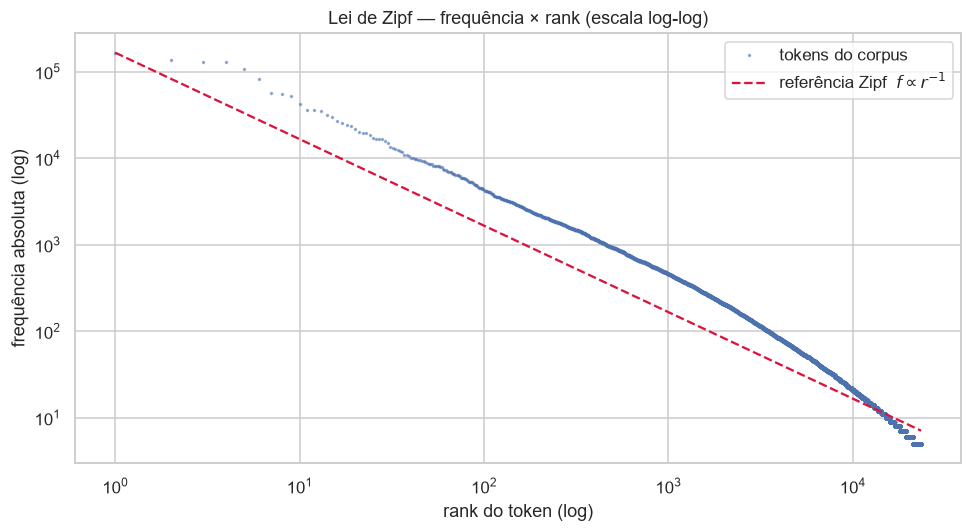

In [16]:
ranks = np.arange(1, len(vocab) + 1)
freqs = np.array([vocab.freq[i] for i in range(len(vocab))], dtype=np.float64)

fig, ax = plt.subplots()
ax.loglog(ranks, freqs, marker=".", linestyle="none", markersize=2.5,
          alpha=0.5, label="tokens do corpus")

# Reta de referência de Zipf (inclinação -1), ancorada no token mais frequente
ref = freqs[0] / ranks
ax.loglog(ranks, ref, color="crimson", linewidth=1.5, linestyle="--",
          label=r"referência Zipf  $f \propto r^{-1}$")

ax.set_xlabel("rank do token (log)")
ax.set_ylabel("frequência absoluta (log)")
ax.set_title("Lei de Zipf — frequência × rank (escala log-log)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.6 Serialização do vocabulário

Para reprodutibilidade (princípio de engenharia do projeto), serializamos o
`Vocab` em `artefatos/vocab.pkl`. Assim o notebook pode ser reaberto e as etapas
seguintes (Huffman, treino) reutilizam o vocabulário sem recontá-lo.

In [17]:
with open(VOCAB_PATH, "wb") as f:
    pickle.dump(vocab, f)
logger.info("Vocabulário serializado em %s (%.2f MB).",
            VOCAB_PATH, VOCAB_PATH.stat().st_size / 1e6)
print(f"[OK] Vocab salvo: V={len(vocab):,} tokens.")

19:24:32 [INFO] Vocabulário serializado em artefatos\vocab.pkl (1.04 MB).
[OK] Vocab salvo: V=23,485 tokens.


## §5 — Árvore de Huffman e hierarchical softmax

> **Estrutura protagonista: heap (na construção) → árvore binária (no uso).**

Esta etapa transforma as frequências do vocabulário (Etapa 2) na estrutura que
torna o treino tratável. A construção usa uma **min-heap** (via `heapq`) para
parear repetidamente as duas (sub)árvores de menor frequência — o algoritmo
guloso clássico de Huffman (1952), que produz o código de prefixo ótimo em
$O(V \log V)$. A árvore resultante é então usada no hierarchical softmax: cada
palavra recebe um `code` (lista de bits da raiz à folha) e um `path` (lista de
IDs dos nós internos atravessados), e cada nó interno guarda um vetor de
parâmetros $\theta_n \in \mathbb{R}^D$.

### 5.1 Construção via min-heap · 5.2 Codificação de caminhos

In [18]:
import heapq


class HuffmanNode:
    """Nó da árvore de Huffman.

    Uma folha carrega `token_id` (ID da palavra no vocabulário); um nó interno
    carrega `index` (0..V-2), que indexa seu vetor de parâmetros no hierarchical
    softmax. `__slots__` reduz o overhead de memória — há ~2V-1 nós.
    """

    __slots__ = ("freq", "token_id", "index", "left", "right")

    def __init__(self, freq, token_id=None, index=None, left=None, right=None):
        self.freq = freq
        self.token_id = token_id
        self.index = index
        self.left = left
        self.right = right

    @property
    def is_leaf(self) -> bool:
        return self.token_id is not None


@dataclass
class HuffmanTree:
    """Árvore de Huffman do vocabulário, pronta para o hierarchical softmax.

    Atributos
    ---------
    root : HuffmanNode
        Raiz da árvore.
    codes : dict[int, tuple[int, ...]]
        token_id -> sequência de bits (0=esquerda, 1=direita) da raiz à folha.
    paths : dict[int, tuple[int, ...]]
        token_id -> sequência de índices dos nós internos atravessados.
    n_internal : int
        Número de nós internos (= V - 1 para V >= 2).
    theta : np.ndarray
        Matriz (n_internal, D) dos parâmetros do HS. Inicializada em zeros
        (padrão Mikolov para os vetores de saída).
    """

    root: HuffmanNode
    codes: dict
    paths: dict
    n_internal: int
    theta: np.ndarray

    def __len__(self) -> int:
        return len(self.codes)

    @classmethod
    def build(cls, vocab: "Vocab", dim: int = EMBEDDING_DIM) -> "HuffmanTree":
        """Constrói a árvore via algoritmo guloso de Huffman com min-heap.

        Complexidade: O(V log V) — cada uma das V-1 fusões faz O(log V) operações
        de heap. Executada uma única vez.
        """
        # Min-heap inicial: uma folha por palavra, ordenada por frequência.
        # O segundo elemento da tupla é um desempatador inteiro único, que evita
        # comparar objetos HuffmanNode quando há empate de frequência.
        heap = [
            (vocab.freq[tid], tid, HuffmanNode(freq=vocab.freq[tid], token_id=tid))
            for tid in range(len(vocab))
        ]
        heapq.heapify(heap)

        desempate = len(vocab)
        n_internal = 0
        while len(heap) > 1:
            f1, _, n1 = heapq.heappop(heap)
            f2, _, n2 = heapq.heappop(heap)
            pai = HuffmanNode(freq=f1 + f2, index=n_internal, left=n1, right=n2)
            n_internal += 1
            heapq.heappush(heap, (pai.freq, desempate, pai))
            desempate += 1

        root = heap[0][2]
        codes, paths = cls._codificar(root)
        theta = np.zeros((n_internal, dim), dtype=np.float64)
        return cls(root=root, codes=codes, paths=paths,
                   n_internal=n_internal, theta=theta)

    @staticmethod
    def _codificar(root: HuffmanNode) -> tuple[dict, dict]:
        """Percorre a árvore (DFS iterativa) atribuindo code e path a cada folha."""
        codes, paths = {}, {}
        pilha = [(root, (), ())]  # (nó, bits acumulados, índices internos acumulados)
        while pilha:
            no, code, path = pilha.pop()
            if no.is_leaf:
                codes[no.token_id] = code
                paths[no.token_id] = path
            else:
                pilha.append((no.left, code + (0,), path + (no.index,)))
                pilha.append((no.right, code + (1,), path + (no.index,)))
        return codes, paths

In [19]:
# Construção da árvore a partir do vocabulário da Etapa 2
huffman = HuffmanTree.build(vocab)

code_lens = np.array([len(huffman.codes[i]) for i in range(len(vocab))])
print(f"Palavras (folhas):        {len(huffman):,}")
print(f"Nós internos (θ):         {huffman.n_internal:,}  (esperado V-1 = {len(vocab) - 1:,})")
print(f"Matriz theta:             {huffman.theta.shape}  (init zeros)")
print(f"Profundidade  min/média/máx: "
      f"{code_lens.min()} / {code_lens.mean():.2f} / {code_lens.max()}")

# Sanity check estrutural da árvore
assert huffman.n_internal == len(vocab) - 1, "n_internal != V-1"
assert len(huffman.codes) == len(huffman.paths) == len(vocab), "cobertura incompleta"
assert all(len(huffman.codes[i]) == len(huffman.paths[i]) for i in range(len(vocab))), \
    "code e path com comprimentos divergentes"
assert max(max(p) for p in huffman.paths.values() if p) < huffman.n_internal, \
    "índice de nó interno fora da faixa"
# Desigualdade de Kraft: para um código de prefixo completo, Σ 2^-len == 1
kraft = float(np.sum(2.0 ** -code_lens))
assert abs(kraft - 1.0) < 1e-9, f"Kraft != 1 (={kraft})"
print(f"\n[OK] Árvore válida. Igualdade de Kraft: Σ 2^(-|code|) = {kraft:.12f} ≈ 1")

Palavras (folhas):        23,485
Nós internos (θ):         23,484  (esperado V-1 = 23,484)
Matriz theta:             (23484, 100)  (init zeros)
Profundidade  min/média/máx: 5 / 17.38 / 20

[OK] Árvore válida. Igualdade de Kraft: Σ 2^(-|code|) = 1.000000000000 ≈ 1


In [20]:
# Caminhos curtos para palavras frequentes, longos para raras (núcleo do método)
def _mostrar(tid: int) -> None:
    code = huffman.codes[tid]
    bits = "".join(map(str, code)) if len(code) <= 22 else \
        "".join(map(str, code[:22])) + "…"
    print(f"  {vocab.id2token[tid]:<16} freq={vocab.freq[tid]:>7,}  "
          f"|code|={len(code):>2}  code={bits}")

print("Palavras MAIS frequentes (caminhos curtos):")
for tid in range(3):
    _mostrar(tid)
print("\nPalavras MENOS frequentes (caminhos longos):")
for tid in range(len(vocab) - 3, len(vocab)):
    _mostrar(tid)

Palavras MAIS frequentes (caminhos curtos):
  de               freq=167,145  |code|= 5  code=11110
  que              freq=138,069  |code|= 5  code=10111
  o                freq=131,234  |code|= 5  code=10100

Palavras MENOS frequentes (caminhos longos):
  íntimos          freq=      5  |code|=20  code=11101111101010110110
  órbita           freq=      5  |code|=20  code=11101111101010110111
  ótimas           freq=      5  |code|=19  code=0001001110110100110


### 5.3 Validação empírica: $H(W) \le L < H(W) + 1$

Calculamos a **entropia de Shannon** da
distribuição empírica do vocabulário, $H(W) = -\sum_w p(w)\log_2 p(w)$, e o
**comprimento médio de codificação observado** na árvore de Huffman,
$L = \sum_w p(w)\,|\text{code}(w)|$. A teoria (Shannon, 1948; Huffman, 1952)
garante que $H(W) \le L < H(W) + 1$. Comparamos ainda com $\log_2 V$, o
comprimento de um código de **tamanho fixo** (equivalente a uma árvore
perfeitamente balanceada), para evidenciar o ganho de explorar a distribuição de
frequências.

Entropia de Shannon      H(W) = 10.0585 bits
Comprimento médio Huffman   L = 10.0854 bits
Redundância              L - H = 0.0269 bits  (teoria: 0 ≤ L-H < 1)
Código de tamanho fixo  log2(V) = 14.5195 bits

Desigualdade de Huffman: H ≤ L < H+1  ->  10.0585 ≤ 10.0854 < 11.0585
[OK] Limite teórico de Huffman confirmado empiricamente.


C:\Users\hulkd\AppData\Local\Temp\ipykernel_4928\3423751054.py:41: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\hulkd\OneDrive\Documents\Docs estudo\Ceub\Estruturas\Projeto FInal\estruturas-nlp-discursos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


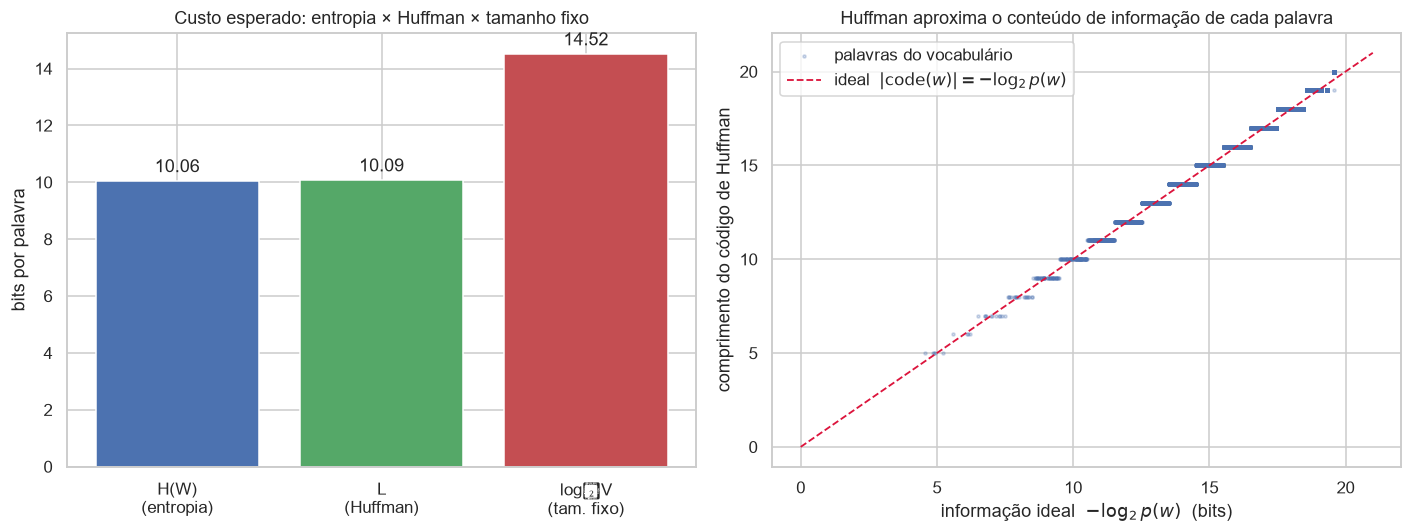

In [21]:
total = vocab.total_tokens
p = np.array([vocab.freq[i] for i in range(len(vocab))], dtype=np.float64) / total

H = float(-(p * np.log2(p)).sum())          # entropia de Shannon (bits)
L = float((p * code_lens).sum())            # comprimento médio de Huffman (bits)
fixo = np.log2(len(vocab))                   # código de tamanho fixo (bits)

print(f"Entropia de Shannon      H(W) = {H:.4f} bits")
print(f"Comprimento médio Huffman   L = {L:.4f} bits")
print(f"Redundância              L - H = {L - H:.4f} bits  (teoria: 0 ≤ L-H < 1)")
print(f"Código de tamanho fixo  log2(V) = {fixo:.4f} bits")
print(f"\nDesigualdade de Huffman: H ≤ L < H+1  ->  "
      f"{H:.4f} ≤ {L:.4f} < {H + 1:.4f}")

assert H <= L < H + 1, "violação do limite de Huffman!"
print("[OK] Limite teórico de Huffman confirmado empiricamente.")

# ----------------------------------------------------------------- Visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (a) H vs L vs código de tamanho fixo
barras = ax1.bar(["H(W)\n(entropia)", "L\n(Huffman)", "log₂V\n(tam. fixo)"],
                 [H, L, fixo],
                 color=["#4C72B0", "#55A868", "#C44E52"])
ax1.bar_label(barras, fmt="%.2f", padding=3)
ax1.set_ylabel("bits por palavra")
ax1.set_title("Custo esperado: entropia × Huffman × tamanho fixo")

# (b) comprimento do código observado × ideal -log2 p(w)
ideal = -np.log2(p)
ax2.scatter(ideal, code_lens, s=4, alpha=0.25, color="#4C72B0",
            label="palavras do vocabulário")
lim = [0, max(ideal.max(), code_lens.max()) + 1]
ax2.plot(lim, lim, "--", color="crimson", linewidth=1.2,
         label=r"ideal  $|\mathrm{code}(w)| = -\log_2 p(w)$")
ax2.set_xlabel(r"informação ideal  $-\log_2 p(w)$  (bits)")
ax2.set_ylabel("comprimento do código de Huffman")
ax2.set_title("Huffman aproxima o conteúdo de informação de cada palavra")
ax2.legend()

plt.tight_layout()
plt.show()

### 5.4 Justificativa: heap + árvore + entropia

**Estruturas e dados armazenados.** Na *construção*, uma **min-heap** (`heapq`)
mantém as (sub)árvores ordenadas pela frequência acumulada, permitindo extrair as
duas de menor peso em $O(\log V)$ por fusão. No *uso*, a estrutura é uma **árvore
binária** em que cada folha é uma palavra e cada um dos $V-1$ nós internos guarda
um vetor $\theta_n \in \mathbb{R}^D$ (os parâmetros do hierarchical softmax).

**Justificativa de complexidade.** A construção é $O(V \log V)$ e ocorre uma única
vez. No treino, cada atualização percorre o caminho da palavra-alvo, com custo
$O\big(|\text{code}(w)|\big)$ — em média $L$ — contra $O(V)$ do softmax denso.
Com $V = $ ~23,5k, isso troca dezenas de milhares de avaliações por algumas
dezenas. A redução é **diretamente justificada por um teorema**: a árvore de
Huffman é o código de prefixo de menor comprimento esperado para a distribuição
empírica, e seu custo médio é limitado pela entropia de Shannon
($H(W) \le L < H(W)+1$), confirmado empiricamente acima.

**Conexão com o ruído controlado.** O hierarchical softmax substitui a
normalização global cara por uma cascata de decisões locais; combinado ao
*subsampling* (Etapa 2) e ao *negative sampling* (stretch), compõe o conjunto de
técnicas que reescrevem o problema de aprendizado em termos de manipulação
controlada de entropia.

### 5.5 Serialização da árvore

Persistimos a árvore (com `codes`, `paths` e a matriz `theta` inicializada) em
`artefatos/huffman_tree.pkl`, para que as Etapas de treino a reutilizem sem
reconstruí-la.

In [22]:
HUFFMAN_PATH = ARTEFATOS_DIR / "huffman_tree.pkl"
with open(HUFFMAN_PATH, "wb") as f:
    pickle.dump(huffman, f)
logger.info("Árvore de Huffman serializada em %s (%.2f MB).",
            HUFFMAN_PATH, HUFFMAN_PATH.stat().st_size / 1e6)
print(f"[OK] Huffman salvo: {len(huffman):,} folhas, {huffman.n_internal:,} nós internos.")

19:24:33 [INFO] Árvore de Huffman serializada em artefatos\huffman_tree.pkl (22.53 MB).
[OK] Huffman salvo: 23,485 folhas, 23,484 nós internos.


## §6 — Mini-autograd: diferenciação automática reversa

> **Estrutura protagonista: pilha (LIFO).**

Para treinar o Skip-gram precisamos de **gradientes**. Em vez de derivar à mão a
regra da cadeia para cada combinação de operações, construímos um *autograd*
mínimo de **modo reverso** (*reverse-mode autodiff*) sobre NumPy — o mesmo
princípio de PyTorch, TensorFlow e JAX, em ~100 linhas.

A ideia: durante o *forward pass*, cada operação é registrada em uma **fita
(tape)** que funciona como uma **pilha** — empilhamos a função de *backward* de
cada operação na ordem em que ela é executada. O *backward pass* então
**desempilha** essa fita, aplicando a regra da cadeia em **ordem reversa** à
execução. Suportamos apenas o necessário para o Skip-gram com *hierarchical
softmax*: indexação de embedding (`embed`), soma (`add`), produto de Hadamard
(`mul`), produto interno (`dot`), `sigmoid` e `log`.

### 6.1 Classe `Tensor` e a fita · 6.2 Operações com *backward*

In [23]:
"""§6.1 — Tensor e a fita (pilha) do grafo computacional.

A fita `_TAPE` é uma PILHA global: cada operação do forward empilha seu
fechamento de backward; `Tensor.backward()` desempilha em ordem reversa (LIFO),
que é exatamente a ordem em que a regra da cadeia deve ser aplicada.
"""

_TAPE: list = []  # pilha de operações do forward pass


def tape_reset() -> None:
    """Esvazia a pilha de operações. Chamar antes de cada novo forward."""
    _TAPE.clear()


def _unbroadcast(grad: np.ndarray, shape: tuple) -> np.ndarray:
    """Reduz `grad` ao formato `shape`, somando os eixos que o broadcasting
    expandiu no forward (garante consistência dimensional no backward)."""
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for eixo, dim in enumerate(shape):
        if dim == 1 and grad.shape[eixo] != 1:
            grad = grad.sum(axis=eixo, keepdims=True)
    return grad.reshape(shape)


class Tensor:
    """Tensor com gradiente, nó do grafo computacional do autograd.

    Atributos
    ---------
    data : np.ndarray
        Valor do tensor.
    grad : np.ndarray
        Gradiente acumulado ∂loss/∂self (inicializado em zeros).
    """

    __slots__ = ("data", "grad")

    def __init__(self, data) -> None:
        self.data = np.asarray(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)

    @property
    def shape(self) -> tuple:
        return self.data.shape

    def backward(self) -> None:
        """Semeia ∂loss/∂loss = 1 e desempilha a fita aplicando a regra da cadeia.

        Push/pop são O(1); o backward percorre a pilha uma única vez, O(n).
        """
        self.grad = np.ones_like(self.data)
        while _TAPE:
            op_backward = _TAPE.pop()  # LIFO: última op do forward = primeira no backward
            op_backward()

    def __repr__(self) -> str:
        return f"Tensor(shape={self.data.shape})"

In [24]:
"""§6.2 — Operações suportadas (o mínimo para o Skip-gram com HS).

Cada função: executa o forward, cria o Tensor de saída e EMPILHA na fita um
fechamento que propaga o gradiente da saída para os operandos (regra da cadeia).
"""

def add(a: Tensor, b: Tensor) -> Tensor:
    """Soma elemento a elemento (com broadcasting)."""
    out = Tensor(a.data + b.data)
    def _backward():
        a.grad = a.grad + _unbroadcast(out.grad, a.data.shape)
        b.grad = b.grad + _unbroadcast(out.grad, b.data.shape)
    _TAPE.append(_backward)
    return out


def mul(a: Tensor, b: Tensor) -> Tensor:
    """Produto de Hadamard (elemento a elemento, com broadcasting)."""
    out = Tensor(a.data * b.data)
    def _backward():
        a.grad = a.grad + _unbroadcast(out.grad * b.data, a.data.shape)
        b.grad = b.grad + _unbroadcast(out.grad * a.data, b.data.shape)
    _TAPE.append(_backward)
    return out


def dot(a: Tensor, b: Tensor) -> Tensor:
    """Produto interno de dois vetores 1-D, resultando em escalar."""
    out = Tensor(np.dot(a.data, b.data))
    def _backward():
        a.grad = a.grad + out.grad * b.data
        b.grad = b.grad + out.grad * a.data
    _TAPE.append(_backward)
    return out


def sigmoid(a: Tensor) -> Tensor:
    """Sigmoide logística σ(x) = 1 / (1 + e^-x)."""
    s = 1.0 / (1.0 + np.exp(-a.data))
    out = Tensor(s)
    def _backward():
        a.grad = a.grad + out.grad * s * (1.0 - s)
    _TAPE.append(_backward)
    return out


def log(a: Tensor) -> Tensor:
    """Logaritmo natural elemento a elemento."""
    out = Tensor(np.log(a.data))
    def _backward():
        a.grad = a.grad + out.grad / a.data
    _TAPE.append(_backward)
    return out


def embed(matriz: Tensor, indices) -> Tensor:
    """Indexa linha(s) de uma matriz de embedding.

    `indices` pode ser um int (retorna vetor (D,)) ou uma sequência de ints
    (retorna (k, D)). O backward usa `np.add.at` para acumular o gradiente nas
    linhas usadas — correto mesmo quando um índice se repete.
    """
    idx = np.asarray(indices)
    out = Tensor(matriz.data[idx])
    def _backward():
        np.add.at(matriz.grad, idx, out.grad)
    _TAPE.append(_backward)
    return out

### 6.3 Justificativa da pilha

**Dado armazenado.** A fita guarda, na ordem de execução do *forward*, as
funções de *backward* de cada operação — cada uma capturando referências aos
tensores operandos e ao tensor resultante.

**Por que LIFO não é escolha, é a estrutura do problema.** A
*backpropagation* aplica a regra da cadeia em **ordem reversa** à do *forward*.
A última operação executada é a primeira a ser diferenciada, e seu gradiente
alimenta as anteriores. Uma pilha (*Last-In, First-Out*) modela exatamente essa
dependência: empilhar na ida, desempilhar na volta. *Push* e *pop* custam $O(1)$;
o *backward* percorre a pilha **uma única vez**, em $O(n)$ no número de
operações. Não há estrutura alternativa que capture a inversão temporal de forma
mais natural.

**Conexão com o estado da arte.** Frameworks reais (PyTorch, TensorFlow, JAX)
implementam o mesmo princípio — com *tape* ou grafo dinâmico —, mas a essência é
idêntica à desta fita.

### 6.4 *Sanity check*: gradiente analítico (autograd) vs numérico

A prova viva de que o autograd está correto: comparamos os gradientes que ele
calcula com os obtidos por **diferenças finitas centrais**
($\partial f/\partial x \approx [f(x+h) - f(x-h)] / 2h$), que não dependem de
nenhuma derivada implementada à mão. Para exercitar todas as operações,
reproduzimos uma atualização de *hierarchical softmax*: a partir do vetor de uma
palavra-centro e dos vetores de dois nós internos (com sinais $\pm 1$ dados pelos
bits do código de Huffman), computamos $-\log \sigma(\pm\, v \cdot \theta)$. A
diferença máxima esperada é $< 10^{-5}$.

In [25]:
# Configuração determinística do teste
rng_check = np.random.default_rng(0)
V0, D = 6, 5
W_in0 = rng_check.standard_normal((V0, D))
Theta0 = rng_check.standard_normal((V0, D))
centro = 2
nos = [0, 4]
sinais = [+1.0, -1.0]   # bits do código de Huffman: +1 (b=0) / -1 (b=1)


def forward_loss(W_in_data: np.ndarray, Theta_data: np.ndarray):
    """Reproduz uma atualização de hierarchical softmax e devolve (loss, W_in, Theta).

    Exercita embed, dot, mul, sigmoid, log e add. O vetor-centro `v` é consumido
    por dois nós, exercitando também a ACUMULAÇÃO de gradiente.
    """
    tape_reset()
    W_in, Theta = Tensor(W_in_data), Tensor(Theta_data)
    v = embed(W_in, centro)                              # vetor da palavra-centro (D,)
    perda = Tensor(0.0)
    for n, sgn in zip(nos, sinais):
        theta_n = embed(Theta, n)                        # vetor do nó interno (D,)
        score = mul(dot(v, theta_n), Tensor(sgn))        # ±(v · θ)
        p = sigmoid(score)
        perda = add(perda, mul(Tensor(-1.0), log(p)))    # acumula -log σ(±v·θ)
    return perda, W_in, Theta


# Gradiente analítico (autograd)
perda, W_in, Theta = forward_loss(W_in0, Theta0)
perda.backward()
g_Win_auto, g_Theta_auto = W_in.grad.copy(), Theta.grad.copy()


# Gradiente numérico (diferenças finitas centrais)
def _loss_val(W_in_data, Theta_data) -> float:
    perda, _, _ = forward_loss(W_in_data, Theta_data)
    return float(perda.data)


def _grad_numerico(param: np.ndarray, h: float = 1e-5) -> np.ndarray:
    g = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        i = it.multi_index
        orig = param[i]
        param[i] = orig + h; mais = _loss_val(W_in0, Theta0)
        param[i] = orig - h; menos = _loss_val(W_in0, Theta0)
        param[i] = orig
        g[i] = (mais - menos) / (2 * h)
        it.iternext()
    return g


g_Win_num = _grad_numerico(W_in0)
g_Theta_num = _grad_numerico(Theta0)

err_Win = float(np.max(np.abs(g_Win_auto - g_Win_num)))
err_Theta = float(np.max(np.abs(g_Theta_auto - g_Theta_num)))
print(f"Perda no ponto de teste              : {float(perda.data):.6f}")
print(f"Erro máx |autograd - numérico| W_in  : {err_Win:.2e}")
print(f"Erro máx |autograd - numérico| Theta : {err_Theta:.2e}")

assert err_Win < 1e-5 and err_Theta < 1e-5, "gradiente do autograd divergente!"
print("\n[OK] Autograd validado: gradientes batem com diferenças finitas (< 1e-5).")

Perda no ponto de teste              : 1.898390
Erro máx |autograd - numérico| W_in  : 1.35e-11
Erro máx |autograd - numérico| Theta : 2.69e-11

[OK] Autograd validado: gradientes batem com diferenças finitas (< 1e-5).


## §7 — Modelo Skip-gram com *hierarchical softmax*

> **Estruturas combinadas: dicionário (vocabulário) + árvore de Huffman + autograd (pilha).**

Aqui as três estruturas anteriores se encontram. O modelo tem duas matrizes de
parâmetros:

- $W_{\text{in}} \in \mathbb{R}^{V \times D}$ — os **embeddings de entrada** (vetores
  das palavras-centro). São o produto final do trabalho. Inicialização: uniforme
  em $[-0{,}5/D,\, +0{,}5/D]$ (padrão Mikolov) — pequena o bastante para não
  saturar a sigmoide, mas não-nula, para quebrar a simetria entre dimensões.
- $W_{\text{out}} \in \mathbb{R}^{(V-1) \times D}$ — os vetores dos **nós internos**
  da árvore de Huffman (os parâmetros $\theta_n$ do *hierarchical softmax*).
  Inicialização: **zeros** (padrão Mikolov), o que faz a árvore começar
  "imparcial": $\sigma(0) = 0{,}5$ em cada nó.

**Forward + loss.** Para um par (palavra-centro $c$, palavra-contexto $o$),
tomamos $v_c = W_{\text{in}}[c]$ e percorremos o caminho de $o$ na árvore de
Huffman. Em cada nó interno $n_j$ do caminho, com bit $b_j$ do código de $o$:

$$ \mathcal{L}(c, o) = -\sum_{j} \log \sigma\!\Big( (1 - 2b_j)\, v_c \cdot \theta_{n_j} \Big), $$

onde $(1 - 2b_j)$ vale $+1$ para $b_j = 0$ e $-1$ para $b_j = 1$. O custo é
$O(|\text{code}(o)|) \approx O(\log V)$ por par — não $O(V)$. O *backward* é
inteiramente delegado ao autograd da §6: basta encadear `embed`, `dot`, `mul`,
`sigmoid` e `log`, e chamar `.backward()`.

### 7.1 Inicialização das matrizes · 7.2 Forward + loss

In [26]:
class SkipGramHS:
    """Modelo Skip-gram com hierarchical softmax.

    Une as três estruturas do projeto:
      - vocabulário (dicionário) -> IDs e frequências;
      - árvore de Huffman        -> códigos e caminhos de cada palavra;
      - autograd (pilha)         -> forward encadeado + backward automático.

    Parâmetros
    ----------
    vocab : Vocab
        Vocabulário da Etapa 2.
    huffman : HuffmanTree
        Árvore da Etapa 3 (fornece codes/paths e o número de nós internos).
    dim : int
        Dimensão D dos embeddings.
    seed : int
        Semente para a inicialização de W_in (reprodutibilidade).
    """

    def __init__(self, vocab: "Vocab", huffman: "HuffmanTree",
                 dim: int = EMBEDDING_DIM, seed: int = SEED) -> None:
        rng = np.random.default_rng(seed)
        limite = 0.5 / dim
        # W_in: embeddings de entrada (centro) — uniforme [-0.5/D, +0.5/D]
        self.W_in = Tensor(rng.uniform(-limite, limite, size=(len(vocab), dim)))
        # W_out: vetores dos nós internos da árvore (HS) — zeros
        self.W_out = Tensor(np.zeros((huffman.n_internal, dim)))
        self.vocab = vocab
        self.huffman = huffman
        self.dim = dim

    def forward(self, centro_id: int, contexto_id: int) -> "Tensor":
        """Loss de hierarchical softmax para o par (centro, contexto).

        Percorre o caminho da palavra-contexto na árvore de Huffman, acumulando
        -log σ(±, v_c · θ_n) em cada nó interno. Retorna um Tensor escalar.
        """
        v_c = embed(self.W_in, centro_id)                 # vetor da palavra-centro (D,)
        codigo = self.huffman.codes[contexto_id]
        caminho = self.huffman.paths[contexto_id]
        perda = Tensor(0.0)
        for bit, no in zip(codigo, caminho):
            sinal = Tensor(1.0 - 2.0 * bit)               # b=0 -> +1 ; b=1 -> -1
            score = mul(dot(v_c, embed(self.W_out, no)), sinal)
            perda = add(perda, mul(Tensor(-1.0), log(sigmoid(score))))
        return perda

    def parametros(self) -> list:
        """Lista de tensores treináveis (para o loop de treino da Etapa 6)."""
        return [self.W_in, self.W_out]

In [27]:
# Instanciação e checagem da inicialização
modelo = SkipGramHS(vocab, huffman)
lim = 0.5 / EMBEDDING_DIM

print(f"W_in : {modelo.W_in.shape}  (V x D)   -> embeddings de entrada (centro)")
print(f"W_out: {modelo.W_out.shape}  (V-1 x D) -> nós internos do hierarchical softmax")
print(f"\nW_in  ∈ [{modelo.W_in.data.min():+.5f}, {modelo.W_in.data.max():+.5f}]  "
      f"(limite teórico ±{lim:.5f})")
print(f"W_out tudo zero? {np.all(modelo.W_out.data == 0.0)}")

assert modelo.W_in.shape == (len(vocab), EMBEDDING_DIM), "shape de W_in incorreto"
assert modelo.W_out.shape == (huffman.n_internal, EMBEDDING_DIM), "shape de W_out incorreto"
assert modelo.W_in.data.min() >= -lim and modelo.W_in.data.max() <= lim, "W_in fora do intervalo"
print("\n[OK] Matrizes inicializadas conforme o padrão Mikolov.")

W_in : (23485, 100)  (V x D)   -> embeddings de entrada (centro)
W_out: (23484, 100)  (V-1 x D) -> nós internos do hierarchical softmax

W_in  ∈ [-0.00500, +0.00500]  (limite teórico ±0.00500)
W_out tudo zero? True

[OK] Matrizes inicializadas conforme o padrão Mikolov.


### 7.3 *Sanity checks* do forward e do gradiente

Três verificações, cada uma explorando uma propriedade conhecida:

1. **Loss inicial determinística.** Com $W_{\text{out}} = 0$, todo *score* é zero,
   $\sigma(0) = 0{,}5$, e cada nó do caminho contribui $-\log 0{,}5 = \ln 2$. Logo a
   loss inicial de qualquer par é exatamente $|\text{code}(o)| \cdot \ln 2$,
   independente de $W_{\text{in}}$ — um valor previsível que confirma o forward.
2. **Localidade do gradiente.** Uma única atualização só pode afetar a linha da
   palavra-centro em $W_{\text{in}}$ e os nós do caminho em $W_{\text{out}}$.
   *Observação esperada:* na inicialização, $W_{\text{in}}$ recebe gradiente
   **nulo** (pois $\partial \mathcal{L}/\partial v_c$ depende de $\theta_n$, que é
   zero); o sinal flui primeiro para $W_{\text{out}}$. Após as primeiras
   atualizações, $W_{\text{out}} \ne 0$ e $W_{\text{in}}$ passa a aprender.
3. **Gradiente numérico vs analítico (end-to-end).** Repetimos a checagem da §6.3,
   agora através de *todas* as estruturas reais (vocabulário + Huffman + modelo),
   confirmando que a integração está correta (diferença $< 10^{-5}$).

In [28]:
import math

# Par de teste com palavras reais (com fallback para IDs válidos)
def _id(token: str, fallback: int) -> int:
    return vocab.token2id.get(token, fallback)

centro = _id("governo", 100)
contexto = _id("saúde", 200)
codigo_ctx = huffman.codes[contexto]
caminho_ctx = huffman.paths[contexto]
print(f"Par de teste: centro='{vocab.id2token[centro]}' -> "
      f"contexto='{vocab.id2token[contexto]}' (|code|={len(codigo_ctx)})")

# (1) Loss inicial determinística
tape_reset()
perda = modelo.forward(centro, contexto)
esperado = len(codigo_ctx) * math.log(2)
print(f"\n(1) Loss inicial: {float(perda.data):.6f} | esperado |code|·ln2 = {esperado:.6f}")
assert abs(float(perda.data) - esperado) < 1e-9, "loss inicial != |code|·ln2"

# Backward (analítico)
perda.backward()

# (2) Localidade do gradiente
linhas_win_nonzero = np.where(np.any(modelo.W_in.grad != 0, axis=1))[0]
linhas_wout_nonzero = set(np.where(np.any(modelo.W_out.grad != 0, axis=1))[0])
print(f"\n(2) Linhas de W_in com gradiente != 0: {list(linhas_win_nonzero)}  "
      f"(esperado vazio na init)")
print(f"    Linhas de W_out com gradiente != 0: {sorted(linhas_wout_nonzero)}")
print(f"    Caminho de Huffman do contexto:     {sorted(set(caminho_ctx))}")
assert linhas_wout_nonzero == set(caminho_ctx), "gradiente de W_out fora do caminho!"
assert len(linhas_win_nonzero) == 0, "W_in deveria ter gradiente nulo na init (W_out=0)"

# (3) Gradiente numérico vs analítico (end-to-end, através das estruturas reais)
def _loss_pair() -> float:
    tape_reset()
    return float(modelo.forward(centro, contexto).data)

def _erro_numerico(matriz_data, linhas, grad_analitico, h=1e-5) -> float:
    pior = 0.0
    for r in linhas:
        for k in range(matriz_data.shape[1]):
            orig = matriz_data[r, k]
            matriz_data[r, k] = orig + h; mais = _loss_pair()
            matriz_data[r, k] = orig - h; menos = _loss_pair()
            matriz_data[r, k] = orig
            pior = max(pior, abs((mais - menos) / (2 * h) - grad_analitico[r, k]))
    return pior

err_wout = _erro_numerico(modelo.W_out.data, list(caminho_ctx)[:3], modelo.W_out.grad)
err_win = _erro_numerico(modelo.W_in.data, [centro], modelo.W_in.grad)
print(f"\n(3) Erro máx |autograd - numérico| W_out (nós do caminho): {err_wout:.2e}")
print(f"    Erro máx |autograd - numérico| W_in  (linha centro)   : {err_win:.2e}")
assert err_wout < 1e-5 and err_win < 1e-5, "gradiente end-to-end divergente!"
print("\n[OK] Modelo Skip-gram + HS validado de ponta a ponta.")

Par de teste: centro='governo' -> contexto='saúde' (|code|=10)

(1) Loss inicial: 6.931472 | esperado |code|·ln2 = 6.931472

(2) Linhas de W_in com gradiente != 0: []  (esperado vazio na init)
    Linhas de W_out com gradiente != 0: [np.int64(23040), np.int64(23236), np.int64(23346), np.int64(23409), np.int64(23444), np.int64(23463), np.int64(23474), np.int64(23479), np.int64(23482), np.int64(23483)]
    Caminho de Huffman do contexto:     [23040, 23236, 23346, 23409, 23444, 23463, 23474, 23479, 23482, 23483]

(3) Erro máx |autograd - numérico| W_out (nós do caminho): 4.17e-11
    Erro máx |autograd - numérico| W_in  (linha centro)   : 0.00e+00

[OK] Modelo Skip-gram + HS validado de ponta a ponta.


## §8 — Loop de treino

> **Estruturas usadas: todas as anteriores + geradores/iteradores.**

O treino é o *Skip-gram* clássico: SGD robusto,
atualizando os parâmetros a cada par (centro, contexto). O fluxo:

1. **Gerador de pares.** Para cada discurso, aplicamos o *subsampling* da Etapa 2
   (descartamos o token $w$ com probabilidade $1 - p_{\text{keep}}(w)$); para cada
   token-centro restante, sorteamos a janela $c \in [1, 5]$ uniformemente e
   emitimos os pares (centro, contexto) com os vizinhos dentro da janela.
2. **Atualização.** Para cada par, `forward` → `backward` (autograd da §6) →
   passo de SGD. Como só a linha da palavra-centro em $W_{\text{in}}$ e os nós do
   caminho em $W_{\text{out}}$ recebem gradiente, atualizamos e zeramos **apenas
   essas linhas** — o passo é $O(|\text{code}|\cdot D)$, coerente com o desenho
   $O(\log V)$ do modelo.
3. **Taxa de aprendizado.** Decaimento linear de $0{,}025$ a $0{,}0001$ ao longo
   das épocas.
4. **Monitoramento.** Perda média a cada $N$ pares, plotada ao final.

Abaixo há um ***smoke test*** rápido num subconjunto (valida a mecânica do loop) e o **treino completo atrás de um flag** (`EXECUTAR_TREINO_COMPLETO`), para ser executado localmente.

In [29]:
EMBEDDINGS_PATH = ARTEFATOS_DIR / "embeddings.npy"


def construir_sequencias(corpus_tokens: list[list[str]], vocab: "Vocab") -> list[list[int]]:
    """Converte o corpus tokenizado em sequências de IDs (descartando OOV).

    Mantém apenas documentos com >= 2 tokens no vocabulário (necessário para
    formar ao menos um par centro-contexto).
    """
    seqs = []
    for tokens in corpus_tokens:
        ids = [vocab.token2id[t] for t in tokens if t in vocab.token2id]
        if len(ids) >= 2:
            seqs.append(ids)
    return seqs


def centros_esperados(seqs: list[list[int]], vocab: "Vocab") -> float:
    """Número esperado de tokens-centro após o subsampling (para o schedule de lr)."""
    return sum(vocab.prob_keep[i] for ids in seqs for i in ids)


def gerar_alvos(seqs, vocab, rng, janela: int = WINDOW):
    """Gera pares (centro, [contextos]) por documento.

    Aplica subsampling por token e, para cada centro, sorteia a janela efetiva
    em [1, janela] e coleta os vizinhos dentro dela. Retorna o centro com a sua
    lista de contextos (agrupar por centro permite ajustar a lr uma vez por
    token, à la word2vec).
    """
    for ids in seqs:
        mantidos = [i for i in ids if rng.random() < vocab.prob_keep[i]]
        n = len(mantidos)
        for pos in range(n):
            b = int(rng.integers(1, janela + 1))
            ini, fim = max(0, pos - b), min(n, pos + b + 1)
            contextos = [mantidos[j] for j in range(ini, fim) if j != pos]
            if contextos:
                yield mantidos[pos], contextos

In [30]:
import time


def treinar(model, seqs, vocab, huffman, *, epocas, lr_start, lr_end,
            total_centros_lr, monitorar_cada=10000, max_pares=None, seed=SEED):
    """Treina o Skip-gram com SGD par a par (forward/backward via autograd).

    Atualiza e zera apenas as linhas tocadas (centro em W_in; nós do caminho em
    W_out), mantendo cada passo em O(|code|·D). Retorna o histórico
    [(pares_acumulados, perda_média), ...] para a curva de perda.
    """
    rng = np.random.default_rng(seed)
    historico = []
    perda_acc, n_acc = 0.0, 0
    centros_proc, pares = 0, 0
    t0 = time.time()

    for ep in range(epocas):
        for centro, contextos in gerar_alvos(seqs, vocab, rng):
            frac = min(1.0, centros_proc / max(total_centros_lr, 1))
            lr = max(lr_end, lr_start - (lr_start - lr_end) * frac)
            for contexto in contextos:
                tape_reset()
                perda = model.forward(centro, contexto)
                perda.backward()
                caminho = list(huffman.paths[contexto])  # lista p/ fancy indexing (tupla -> índice multidim)
                model.W_in.data[centro] -= lr * model.W_in.grad[centro]
                model.W_out.data[caminho] -= lr * model.W_out.grad[caminho]
                model.W_in.grad[centro] = 0.0       # zera só as linhas tocadas
                model.W_out.grad[caminho] = 0.0
                perda_acc += float(perda.data); n_acc += 1; pares += 1
                if n_acc >= monitorar_cada:
                    historico.append((pares, perda_acc / n_acc))
                    logger.info("época %d | pares %d | lr %.5f | perda média %.4f",
                                ep + 1, pares, lr, perda_acc / n_acc)
                    perda_acc, n_acc = 0.0, 0
                if max_pares and pares >= max_pares:
                    logger.info("Limite de %d pares atingido.", max_pares)
                    return historico, pares, time.time() - t0
            centros_proc += 1

    return historico, pares, time.time() - t0

### 8.3 *Smoke test* do loop (overfit acelerado)

Validação da mecânica do treino: confirmamos que a perda **decresce** quando o loop roda. Usamos o teste canônico de *overfit* — pouquíssimos discursos (5, truncados a 40 tokens), muitas épocas (30) e **taxa de aprendizado alta** (0,25 → 0,05) — para forçar o modelo a *memorizar* esse conjunto minúsculo e a perda a cair de forma visível em poucos segundos. Não é treino de qualidade (os hiperparâmetros reais estão no §8.4); é a prova de que `forward` → `backward` → SGD efetivamente minimizam a perda.

19:24:34 [INFO] época 4 | pares 500 | lr 0.22875 | perda média 7.9824
19:24:34 [INFO] época 7 | pares 1000 | lr 0.20658 | perda média 6.4333
19:24:34 [INFO] época 11 | pares 1500 | lr 0.18349 | perda média 5.6543
19:24:35 [INFO] época 14 | pares 2000 | lr 0.16077 | perda média 4.9855
19:24:35 [INFO] época 18 | pares 2500 | lr 0.13714 | perda média 4.2414
19:24:35 [INFO] época 21 | pares 3000 | lr 0.11460 | perda média 4.0954
19:24:35 [INFO] época 25 | pares 3500 | lr 0.09188 | perda média 3.8964
19:24:35 [INFO] época 28 | pares 4000 | lr 0.07081 | perda média 3.7169

Pares treinados: 4,431 em 1.8s  (2,473 pares/s)
Perda inicial (1ª janela): 7.9824 | perda final: 3.7169


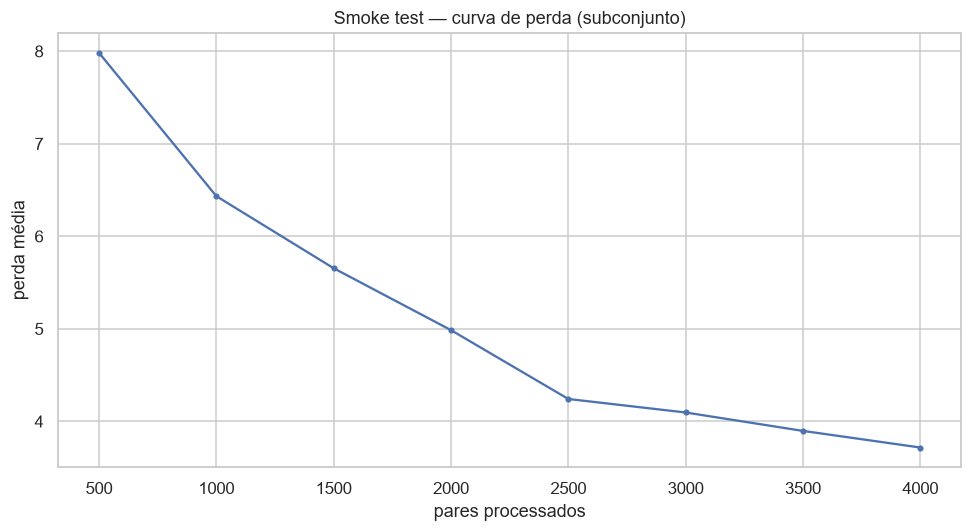

In [31]:
# Subconjunto pequeno para validar a mecânica (não a qualidade)
seqs_smoke = [s[:40] for s in construir_sequencias(corpus_tokenizado, vocab)[:5]]
total_c_smoke = 30 * centros_esperados(seqs_smoke, vocab)  # 30 épocas

modelo_smoke = SkipGramHS(vocab, huffman)
hist_smoke, n_pares, dt = treinar(
    modelo_smoke, seqs_smoke, vocab, huffman,
    epocas=30, lr_start=0.25, lr_end=0.05,  # lr alto: smoke acelerado
    total_centros_lr=total_c_smoke, monitorar_cada=500, max_pares=50000,
)
print(f"\nPares treinados: {n_pares:,} em {dt:.1f}s  ({n_pares / max(dt, 1e-9):,.0f} pares/s)")
if hist_smoke:
    print(f"Perda inicial (1ª janela): {hist_smoke[0][1]:.4f} | "
          f"perda final: {hist_smoke[-1][1]:.4f}")

# Curva de perda do smoke
if len(hist_smoke) >= 2:
    xs, ys = zip(*hist_smoke)
    fig, ax = plt.subplots()
    ax.plot(xs, ys, marker="o", markersize=3)
    ax.set_xlabel("pares processados"); ax.set_ylabel("perda média")
    ax.set_title("Smoke test — curva de perda (subconjunto)")
    plt.tight_layout(); plt.show()

# (Os embeddings finais são gerados pelo treino completo do §8.4 e
# salvos em embeddings.npy; o smoke não os sobrescreve.)


### 8.4 Treino completo

Treino real sobre todo o corpus, com os hiperparâmetros do projeto (5 épocas,
lr $0{,}025 \to 0{,}0001$).

In [32]:
EXECUTAR_TREINO_COMPLETO = False 

if EXECUTAR_TREINO_COMPLETO:
    seqs_full = construir_sequencias(corpus_tokenizado, vocab)
    total_c_full = EPOCHS * centros_esperados(seqs_full, vocab)
    logger.info("Treino completo: %d documentos, ~%.0f centros/época.",
                len(seqs_full), total_c_full / EPOCHS)

    modelo = SkipGramHS(vocab, huffman)   # modelo fresco, do zero
    hist_full, n_pares, dt = treinar(
        modelo, seqs_full, vocab, huffman,
        epocas=EPOCHS, lr_start=LR_START, lr_end=LR_END,
        total_centros_lr=total_c_full, monitorar_cada=50000,
    )
    np.save(EMBEDDINGS_PATH, modelo.W_in.data)
    logger.info("Treino completo: %d pares em %.0fs. Embeddings salvos em %s.",
                n_pares, dt, EMBEDDINGS_PATH)

    if len(hist_full) >= 2:
        xs, ys = zip(*hist_full)
        fig, ax = plt.subplots()
        ax.plot(xs, ys)
        ax.set_xlabel("pares processados"); ax.set_ylabel("perda média")
        ax.set_title("Treino completo — curva de perda")
        plt.tight_layout(); plt.show()
else:
    print("Treino completo desativado (EXECUTAR_TREINO_COMPLETO=False).")
    print("Defina o flag como True e execute localmente para gerar os embeddings finais.")

Treino completo desativado (EXECUTAR_TREINO_COMPLETO=False).
Defina o flag como True e execute localmente para gerar os embeddings finais.


## §9 — Inspeção qualitativa dos embeddings

Com os embeddings treinados (`artefatos/embeddings.npy`), avaliamos
qualitativamente o que o modelo aprendeu: (9.1) os **vizinhos mais próximos**
de palavras-sonda no espaço vetorial, pela **similaridade do cosseno**; e
(9.2) uma **projeção 2D** (t-SNE) de um conjunto temático de termos, para
inspecionar visualmente se regiões semânticas emergem.

> **Pré-requisito.** Esta seção (e a busca semântica das §10–§11) exige o
> arquivo `artefatos/embeddings.npy`, produzido pelo **treino completo**
> (§8.4, `EXECUTAR_TREINO_COMPLETO = True`). Sem ele, as células abaixo falham
> com `FileNotFoundError`.

In [33]:
# Carrega os embeddings treinados (matriz V x D) e normaliza para o cosseno
W = np.load(EMBEDDINGS_PATH)
assert W.shape == (len(vocab), EMBEDDING_DIM), "embeddings incompatíveis com o vocabulário"

# Normalização L2 por linha: com vetores unitários, cosseno = produto interno.
_normas = np.linalg.norm(W, axis=1, keepdims=True)
_normas[_normas == 0.0] = 1.0           # evita divisão por zero (vetores ainda no init)
W_norm = W / _normas

print(f"Embeddings carregados: {W.shape} de {EMBEDDINGS_PATH}")
print(f"Vetores não-nulos (treinados): {int((np.linalg.norm(W, axis=1) > 1e-8).sum()):,} / {len(vocab):,}")

Embeddings carregados: (23485, 100) de artefatos\embeddings.npy
Vetores não-nulos (treinados): 23,485 / 23,485


In [34]:
def vizinhos(token: str, k: int = 10) -> list[tuple[str, float]]:
    """Retorna os k tokens de maior similaridade do cosseno com `token`.

    Parâmetros
    ----------
    token : str
        Palavra-consulta (deve estar no vocabulário).
    k : int
        Número de vizinhos a retornar.

    Retorna
    -------
    list[tuple[str, float]]
        Pares (token_vizinho, similaridade), em ordem decrescente.
    """
    idx = vocab.token2id.get(token)
    if idx is None:
        raise KeyError(f"'{token}' não está no vocabulário.")
    sims = W_norm @ W_norm[idx]            # cosseno contra todo o vocabulário, O(V·D)
    sims[idx] = -np.inf                    # exclui o próprio token
    topo = np.argpartition(-sims, k)[:k]   # k maiores sem ordenar tudo, O(V)
    topo = topo[np.argsort(-sims[topo])]   # ordena apenas os k
    return [(vocab.id2token[i], float(sims[i])) for i in topo]


def tabela_vizinhos(tokens: list[str], k: int = 10) -> None:
    """Imprime os k vizinhos de cada token-sonda presente no vocabulário."""
    for tok in tokens:
        if tok not in vocab:
            print(f"\n[{tok}] — fora do vocabulário, pulando.")
            continue
        viz = vizinhos(tok, k)
        print(f"\n[{tok}]  (freq={vocab.freq_de(tok):,})")
        for w, s in viz:
            print(f"    {s:+.3f}  {w}")

In [35]:
# Tokens-sonda: temas recorrentes em discursos parlamentares
sondas = ["saúde", "educação", "imposto", "criança", "agricultura",
          "indígena", "segurança", "trabalhador"]
tabela_vizinhos(sondas, k=10)


[saúde]  (freq=4,140)
    +0.803  sus
    +0.759  atendimento
    +0.756  pacientes
    +0.726  tratamento
    +0.718  psicólogos
    +0.709  cuidados
    +0.694  acesso
    +0.691  condições
    +0.690  suporte
    +0.688  oncológicos

[educação]  (freq=3,418)
    +0.764  qualidade
    +0.736  valorização
    +0.735  docente
    +0.734  ensino
    +0.727  estudantes
    +0.710  alunos
    +0.705  escolas
    +0.705  qualificação
    +0.700  formação
    +0.697  escolares

[imposto]  (freq=1,531)
    +0.894  isenção
    +0.852  ganha
    +0.851  isentar
    +0.837  impostos
    +0.827  tributar
    +0.810  pagam
    +0.808  isentos
    +0.806  renda
    +0.793  alíquota
    +0.792  super

[criança]  (freq=791)
    +0.848  adolescente
    +0.712  eca
    +0.710  gestante
    +0.695  pornografia
    +0.680  bullying
    +0.678  psicológica
    +0.677  crianças
    +0.677  estatuto
    +0.670  adolescentes
    +0.650  sexual

[agricultura]  (freq=687)
    +0.778  pecuária
    +0.760  fam

### 9.2 Visualização 2D (t-SNE)

Projetamos um conjunto curado de termos, agrupados manualmente por tema, do
espaço de $D = 100$ dimensões para 2D via **t-SNE**. Se os embeddings
capturaram estrutura semântica, termos do mesmo tema devem formar agrupamentos
(*clusters*) visíveis. A coloração por tema é uma rotulagem manual, apenas para
leitura — não influencia a projeção.

Termos projetados: 30 de 30


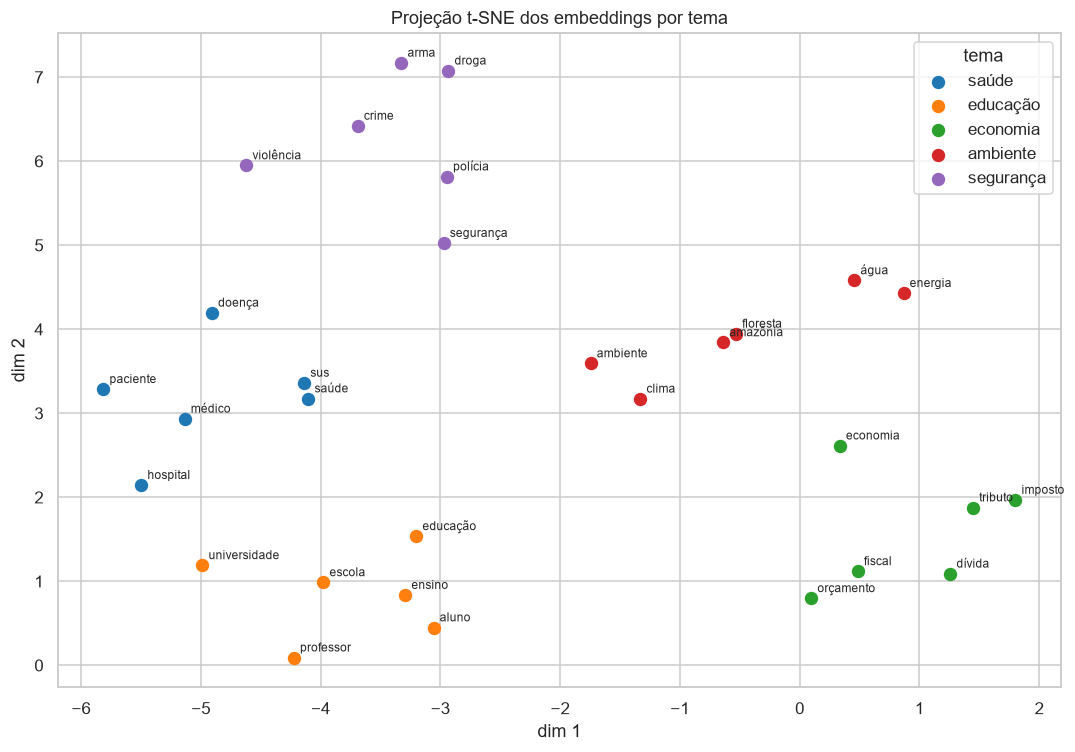

In [36]:
from sklearn.manifold import TSNE

# Grupos temáticos manuais (apenas para coloração da projeção)
grupos = {
    "saúde":      ["saúde", "hospital", "médico", "sus", "doença", "paciente"],
    "educação":   ["educação", "escola", "professor", "aluno", "universidade", "ensino"],
    "economia":   ["imposto", "tributo", "economia", "orçamento", "dívida", "fiscal"],
    "ambiente":   ["ambiente", "clima", "floresta", "amazônia", "água", "energia"],
    "segurança":  ["segurança", "polícia", "violência", "crime", "droga", "arma"],
}

# Mantém apenas termos presentes no vocabulário
termos, rotulos, cores_idx = [], [], []
for ci, (tema, palavras) in enumerate(grupos.items()):
    for p in palavras:
        if p in vocab:
            termos.append(p); rotulos.append(tema); cores_idx.append(ci)
print(f"Termos projetados: {len(termos)} de {sum(len(v) for v in grupos.values())}")

# t-SNE sobre os vetores (normalizados) dos termos selecionados
M = np.array([W_norm[vocab.token2id[t]] for t in termos])
perplex = max(2, min(15, len(termos) - 1))
coords = TSNE(n_components=2, perplexity=perplex, init="pca",
              random_state=SEED).fit_transform(M)

# Scatter colorido por tema, com rótulos
fig, ax = plt.subplots(figsize=(10, 7))
paleta = sns.color_palette("tab10", n_colors=len(grupos))
for ci, tema in enumerate(grupos):
    sel = [j for j, c in enumerate(cores_idx) if c == ci]
    ax.scatter(coords[sel, 0], coords[sel, 1], s=60, color=paleta[ci], label=tema)
for j, t in enumerate(termos):
    ax.annotate(t, (coords[j, 0], coords[j, 1]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_title("Projeção t-SNE dos embeddings por tema")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
ax.legend(title="tema", loc="best")
plt.tight_layout(); plt.show()

## §10 — Indexação semântica (HNSW)

> **Estrutura protagonista: grafo (HNSW — *Hierarchical Navigable Small World*).**

Para responder "quais discursos são semanticamente próximos a esta consulta?"
precisamos de busca de vizinhos mais próximos sobre os vetores dos documentos.
Cada discurso é representado pela **média dos embeddings dos seus tokens**
(Etapa 7), e o conjunto desses vetores é indexado por um **HNSW**
(Malkov & Yashunin, 2016) implementado à mão.

A busca exata custa $O(N \cdot D)$ por consulta (comparar com todos os $N$
documentos). KD-trees dão $O(\log N)$ em baixa dimensão, mas degradam para
$O(N)$ acima de $D \approx 20$ (maldição da dimensionalidade) — e aqui
$D = 100$. O HNSW mantém $O(\log N)$ amortizado mesmo em alta dimensão,
construindo um grafo em camadas: as superiores são esparsas (arestas de longo
alcance, para "saltar" rápido pelo espaço) e as inferiores densas (arestas
curtas, para o refino local). A busca desce as camadas de forma gulosa.

### 10.1 Representação dos documentos

In [37]:
def representar_documentos(corpus_tokens, vocab, embeddings) -> np.ndarray:
    """Representa cada documento pela média (normalizada) dos embeddings dos
    seus tokens presentes no vocabulário.

    Retorna uma matriz (n_docs, D) com vetores L2-normalizados, de modo que a
    similaridade do cosseno entre dois documentos vira o produto interno.
    """
    n_docs, dim = len(corpus_tokens), embeddings.shape[1]
    docs = np.zeros((n_docs, dim), dtype=np.float64)
    for d, tokens in enumerate(corpus_tokens):
        ids = [vocab.token2id[t] for t in tokens if t in vocab.token2id]
        if ids:
            docs[d] = embeddings[ids].mean(axis=0)
    normas = np.linalg.norm(docs, axis=1, keepdims=True)
    normas[normas == 0.0] = 1.0
    return docs / normas


doc_vecs = representar_documentos(corpus_tokenizado, vocab, W)
print(f"Vetores de documentos: {doc_vecs.shape}")
print(f"Documentos com vetor não-nulo: "
      f"{int((np.linalg.norm(doc_vecs, axis=1) > 1e-8).sum()):,} / {len(doc_vecs):,}")

Vetores de documentos: (7997, 100)
Documentos com vetor não-nulo: 7,997 / 7,997


### 10.2 Construção do índice HNSW

In [38]:
import heapq


class HNSW:
    """Índice de vizinhos aproximados (Hierarchical Navigable Small World).

    Trabalha com vetores L2-normalizados, usando como distância
    d(a, b) = 1 - (a · b) (distância de cosseno). A construção insere os nós um
    a um; cada nó recebe um nível por distribuição geométrica, e suas conexões
    em cada camada são os M vizinhos mais próximos encontrados por busca gulosa.

    Parâmetros
    ----------
    dados : np.ndarray
        Matriz (N, D) de vetores normalizados.
    M : int
        Nº de vizinhos por nó nas camadas > 0 (camada 0 usa 2·M).
    ef_construction : int
        Tamanho da lista dinâmica de candidatos durante a construção.
    """

    def __init__(self, dados: np.ndarray, M: int = 16,
                 ef_construction: int = 200, seed: int = SEED) -> None:
        self.dados = dados
        self.M, self.M0 = M, 2 * M
        self.ef_construction = ef_construction
        self.mL = 1.0 / math.log(M)
        self.rng = random.Random(seed)
        self.niveis = [0] * len(dados)
        self.grafo = [None] * len(dados)     # grafo[no][camada] -> lista de vizinhos
        self.entrada = None
        self.nivel_max = -1

    def _busca_camada(self, q, entradas, ef, camada):
        """Busca gulosa numa camada: retorna os `ef` nós mais próximos de `q`.

        Usa duas heaps: `cand` (min-heap por distância, fronteira a explorar) e
        `res` (max-heap de tamanho ef com os melhores encontrados).
        """
        visitados = set(entradas)
        cand, res = [], []
        for e in entradas:
            de = 1.0 - float(self.dados[e] @ q)
            heapq.heappush(cand, (de, e)); heapq.heappush(res, (-de, e))
        while cand:
            d, c = heapq.heappop(cand)
            if d > -res[0][0]:
                break                         # nada mais perto que o pior da lista
            vizs = [v for v in self.grafo[c].get(camada, ()) if v not in visitados]
            if not vizs:
                continue
            dists = 1.0 - self.dados[vizs] @ q   # distâncias vetorizadas
            for v, dv in zip(vizs, dists):
                visitados.add(v); dv = float(dv)
                if dv < -res[0][0] or len(res) < ef:
                    heapq.heappush(cand, (dv, v)); heapq.heappush(res, (-dv, v))
                    if len(res) > ef:
                        heapq.heappop(res)
        return [no for _, no in res]

    def _mais_proximos(self, q, candidatos, M):
        """Seleciona os M candidatos mais próximos de q (seleção simples)."""
        return heapq.nsmallest(M, candidatos, key=lambda i: 1.0 - float(self.dados[i] @ q))

    def inserir(self, i: int) -> None:
        """Insere o nó i no grafo (Algoritmo 1 de Malkov & Yashunin)."""
        nivel = int(-math.log(self.rng.random()) * self.mL)
        self.niveis[i] = nivel
        self.grafo[i] = {}
        q = self.dados[i]
        if self.entrada is None:
            self.entrada, self.nivel_max = i, nivel
            return
        ep = [self.entrada]
        for camada in range(self.nivel_max, nivel, -1):      # desce greedy (ef=1)
            ep = self._busca_camada(q, ep, 1, camada)
        for camada in range(min(self.nivel_max, nivel), -1, -1):
            W_cand = self._busca_camada(q, ep, self.ef_construction, camada)
            Mc = self.M0 if camada == 0 else self.M
            vizinhos = self._mais_proximos(q, W_cand, Mc)
            self.grafo[i][camada] = list(vizinhos)
            for v in vizinhos:                                # arestas bidirecionais
                self.grafo[v].setdefault(camada, []).append(i)
                if len(self.grafo[v][camada]) > Mc:           # poda o nó saturado
                    self.grafo[v][camada] = self._mais_proximos(
                        self.dados[v], self.grafo[v][camada], Mc)
            ep = W_cand
        if nivel > self.nivel_max:
            self.entrada, self.nivel_max = i, nivel

    @classmethod
    def construir(cls, dados, **kwargs) -> "HNSW":
        """Constrói o índice inserindo todos os nós em ordem aleatória."""
        idx = cls(dados, **kwargs)
        ordem = list(range(len(dados)))
        idx.rng.shuffle(ordem)
        for i in ordem:
            idx.inserir(i)
        return idx

    def buscar(self, q: np.ndarray, k: int = 5, ef: int = 64) -> list[int]:
        """Retorna os IDs dos k documentos mais próximos do vetor de consulta q."""
        ep = [self.entrada]
        for camada in range(self.nivel_max, 0, -1):
            ep = self._busca_camada(q, ep, 1, camada)
        W_cand = self._busca_camada(q, ep, max(ef, k), 0)
        return heapq.nsmallest(k, W_cand, key=lambda i: 1.0 - float(self.dados[i] @ q))

In [39]:
import time

t0 = time.time()
indice = HNSW.construir(doc_vecs, M=16, ef_construction=200)
dt = time.time() - t0

graus0 = [len(indice.grafo[i].get(0, [])) for i in range(len(doc_vecs))]
n_arestas = sum(len(viz) for no in indice.grafo for viz in no.values())
print(f"Índice HNSW construído: {len(doc_vecs):,} nós em {dt:.1f}s")
print(f"Nível máximo: {indice.nivel_max} | distribuição de níveis: "
      f"{ {n: indice.niveis.count(n) for n in range(indice.nivel_max + 1)} }")
print(f"Grau médio na camada 0: {np.mean(graus0):.1f} (alvo 2·M = {indice.M0})")
print(f"Arestas direcionadas totais: {n_arestas:,}")

Índice HNSW construído: 7,997 nós em 21.6s
Nível máximo: 4 | distribuição de níveis: {0: 7540, 1: 433, 2: 21, 3: 2, 4: 1}
Grau médio na camada 0: 32.0 (alvo 2·M = 32)
Arestas direcionadas totais: 263,606


In [40]:
# Sanity check: recall@10 do HNSW contra a busca exata (força bruta) numa amostra
def vizinhos_exatos(q, k):
    sims = doc_vecs @ q
    return set(np.argsort(-sims)[:k])

rng_eval = np.random.default_rng(SEED)
amostra = rng_eval.choice(len(doc_vecs), size=100, replace=False)
recalls = []
for qi in amostra:
    aprox = set(indice.buscar(doc_vecs[qi], k=10))
    exato = vizinhos_exatos(doc_vecs[qi], 10)
    recalls.append(len(aprox & exato) / 10)

print(f"Recall@10 (HNSW vs força bruta, {len(amostra)} consultas): {np.mean(recalls):.3f}")
print(f"Consultas com recall perfeito: {sum(r == 1.0 for r in recalls)}/{len(amostra)}")
assert np.mean(recalls) > 0.90, "recall do HNSW abaixo do esperado"
print("\n[OK] HNSW recupera quase exatamente os mesmos vizinhos da busca exata.")

Recall@10 (HNSW vs força bruta, 100 consultas): 0.999
Consultas com recall perfeito: 99/100

[OK] HNSW recupera quase exatamente os mesmos vizinhos da busca exata.


### 10.4 Justificativa do grafo

**Dado armazenado.** Um grafo em camadas: cada nó é um documento (seu vetor
médio), e cada aresta liga documentos próximos no espaço vetorial. As camadas
superiores são esparsas (poucos nós, arestas de longo alcance); a camada 0
contém todos os nós com arestas curtas.

**Justificativa de complexidade.** A busca exata é $O(N \cdot D)$ por consulta.
KD-trees são $O(\log N)$ apenas em baixa dimensão e degradam para varredura
quase completa acima de $D \approx 20$ — com $D = 100$, seriam ineficazes. O
HNSW navega o grafo de forma gulosa, descendo das camadas esparsas às densas,
com custo **$O(\log N)$ amortizado** mesmo em alta dimensão; é o método usado em
FAISS, Pinecone, Qdrant e Weaviate. A construção é $O(N \log N)$. O *recall*
medido acima confirma empiricamente que a aproximação recupera praticamente os
mesmos vizinhos da busca exata, a uma fração do custo.

**Heaps na busca.** Cada busca de camada usa duas heaps: uma min-heap de
candidatos (fronteira de exploração) e uma max-heap de tamanho `ef` com os
melhores resultados — o mesmo princípio de heap que reaparece na busca top-K
da §11.

In [41]:
INDICE_PATH = ARTEFATOS_DIR / "indice_busca.pkl"
with open(INDICE_PATH, "wb") as f:
    pickle.dump(indice, f)
logger.info("Índice HNSW serializado em %s (%.1f MB).",
            INDICE_PATH, INDICE_PATH.stat().st_size / 1e6)
print(f"[OK] Índice salvo: {len(doc_vecs):,} documentos indexados.")

19:25:02 [INFO] Índice HNSW serializado em artefatos\indice_busca.pkl (7.3 MB).
[OK] Índice salvo: 7,997 documentos indexados.


## §11 — Busca semântica top-K

> **Estruturas protagonistas: min-heap de tamanho K + grafo (HNSW).**

Esta seção fecha o pipeline: a função `buscar(query, k)` recebe uma consulta
textual livre, agrega os embeddings dos tokens da consulta (média), percorre o
índice HNSW (§10) para obter um conjunto de candidatos e devolve os **K
documentos mais similares**.

### 11.1 Min-heap de tamanho K

Para selecionar os K melhores entre os N candidatos retornados pelo grafo,
mantemos uma **min-heap de tamanho fixo K**: a cada candidato, se a heap ainda
não tem K elementos, inserimos; caso contrário, só substituímos a raiz (o pior
dos K atuais) quando o novo candidato é melhor. O custo é $O(N \log K)$, contra
$O(N \log N)$ de ordenar todos os candidatos — vantajoso quando $K \ll N$. É a
mesma estrutura de heap usada internamente na busca por camada do HNSW.

In [42]:
import heapq


def buscar(query: str, k: int = 5, ef: int = 80) -> list[tuple[int, float]]:
    """Busca os k discursos mais similares a uma consulta textual.

    Etapas: (1) tokeniza a consulta e agrega os embeddings dos seus tokens
    (média, normalizada); (2) percorre o índice HNSW (descida gulosa pelas
    camadas + pool na camada 0); (3) mantém os K melhores numa min-heap de
    tamanho K, pela similaridade do cosseno.

    Retorna uma lista [(id_documento, similaridade), ...] em ordem decrescente.
    """
    ids = [vocab.token2id[t] for t in tokenizar(query) if t in vocab.token2id]
    if not ids:
        return []
    q = W[ids].mean(axis=0)
    q = q / np.linalg.norm(q)

    # Percorre o grafo HNSW: descida gulosa + pool de candidatos na camada 0
    ep = [indice.entrada]
    for camada in range(indice.nivel_max, 0, -1):
        ep = indice._busca_camada(q, ep, 1, camada)
    pool = indice._busca_camada(q, ep, ef, 0)

    # Min-heap de tamanho K: O(N log K) em vez de O(N log N) de ordenar tudo
    melhores: list[tuple[float, int]] = []
    for doc in pool:
        sim = float(doc_vecs[doc] @ q)
        if len(melhores) < k:
            heapq.heappush(melhores, (sim, doc))
        elif sim > melhores[0][0]:
            heapq.heapreplace(melhores, (sim, doc))
    return [(doc, sim) for sim, doc in sorted(melhores, reverse=True)]


def mostrar_busca(query: str, k: int = 5) -> None:
    """Executa buscar() e imprime os resultados de forma legível."""
    resultados = buscar(query, k)
    print(f'CONSULTA: "{query}"')
    if not resultados:
        print("  (nenhum token da consulta está no vocabulário)")
        return
    for doc, sim in resultados:
        r = corpus.iloc[doc]
        print(f"  [{sim:.3f}] {r['nome_deputado']} ({r['sigla_partido']}-{r['sigla_uf']}, {r['data']})")
        print(f"          {r['sumario'][:140]}")

### 11.2 Demonstração

Três consultas de especificidade crescente: um tema amplo, uma pauta concreta e
uma consulta com vários termos de conteúdo.

In [43]:
mostrar_busca("educação", k=3)
print()
mostrar_busca("reforma tributária e isenção de imposto de renda", k=3)
print()
mostrar_busca("proteção de crianças e adolescentes contra a violência", k=3)

CONSULTA: "educação"
  [0.680] Rubens Otoni (PT-GO, 2024-08-27)
          O Deputado discursou sobre a importância da formação e capacitação de profissionais no setor da mobilidade urbana, destacando a necessidade 
  [0.679] Helder Salomão (PT-ES, 2025-10-15)
          O Deputado, em homenagem ao Dia do Professor, destacou sua trajetória de 18 anos como educador e o compromisso com a valorização dos profiss
  [0.658] Rubens Pereira Júnior (PT-MA, 2025-02-27)
          O Deputado exaltou a gestão do Governador Carlos Brandão na área de educação pública no Maranhão, destacando a entrega de cinco escolas refo

CONSULTA: "reforma tributária e isenção de imposto de renda"
  [0.872] Helder Salomão (PT-ES, 2025-08-26)
          O Deputado defendeu a aprovação do Projeto de Lei nº 1.087, de 2025, que propõe a isenção do Imposto de Renda para quem recebe até R$ 5 mil,
  [0.847] Waldenor Pereira (PT-BA, 2025-10-01)
          O Deputado afirmou que a aprovação do projeto de isenção do Imposto de 

## §12 — Síntese: mapeamento das quatro estruturas

O quadro abaixo consolida como cada estrutura emergiu da matemática do problema,
o que armazena, sua complexidade e o resultado empírico que a valida neste
trabalho.

| # | Estrutura | Etapa | Dado armazenado | Complexidade | Validação empírica |
|---|---|---|---|---|---|
| 1 | **Dicionário** (hash table) | §4 | `token → id`, frequências, `prob_keep`, unigrama⁰·⁷⁵ | acesso $O(1)$; construção $O(N)$ | V = 23.485; 98,4% de cobertura; Lei de Zipf |
| 2 | **Heap → Árvore de Huffman** | §5 | min-heap na construção; árvore com $V-1$ nós internos ($\theta_n$) | construção $O(V\log V)$; treino $O(\log V)$ | $H{=}10{,}06 \le L{=}10{,}09 < H{+}1$; Kraft $=1$ |
| 3 | **Pilha** (fita do autograd) | §6 | fechamentos de *backward* na ordem do *forward* | *push/pop* $O(1)$; *backward* $O(n)$ | erro vs diferenças finitas $\approx 10^{-11}$ |
| 4 | **Grafo** (HNSW) | §10–§11 | grafo navegável em camadas; min-heap de tamanho $K$ na busca | construção $O(N\log N)$; busca $O(\log N)$ | recall@10 $= 0{,}999$ vs força bruta |

As quatro não são ornamentais nem redundantes: o dicionário sustenta a
complexidade do treino; a árvore de Huffman reduz o softmax de $O(V)$ a
$O(\log V)$ com optimalidade garantida por Shannon; a pilha é a forma natural de
inverter a ordem temporal na *backpropagation*; e o grafo torna tratável a busca
de vizinhos em alta dimensão, onde árvores espaciais degradam. O NumPy permanece
como ferramenta numérica de apoio, sem ser contado entre as quatro.

## §13 — Limitações e trabalhos futuros

**Limitações.**

- O treino é SGD puro, par a par, em NumPy de thread único — fiel ao Skip-gram
  clássico, porém custoso e sem aceleração por GPU (decisão de implementar tudo
  do zero).
- A representação de documentos pela média simples dos embeddings ignora a ordem
  e a importância relativa dos termos.
- O *recall* do HNSW, embora altíssimo (0,999), é aproximado por construção.
- A perda do *hierarchical softmax* estabiliza em torno de ~9,0 (soma de
  $-\log\sigma$ ao longo de caminhos de ~10–14 nós); o sinal de qualidade vem da
  inspeção semântica (§9), não do valor absoluto da perda.

**Trabalhos futuros.**

- *Negative sampling* como alternativa ao *hierarchical softmax*, com comparação
  direta — conecta-se à tese de ruído controlado.
- Representação de documentos por média ponderada por TF-IDF.
- Comparação com um modelo pré-treinado de PT-BR (ex.: NILC) como oráculo de
  qualidade.
- Análise de deslocamento semântico temporal (treinar em janelas separadas).
- **Interface de busca e disponibilização (deploy):** expor a busca a usuários
  finais, retornando não só os discursos mais similares, mas agregações úteis —
  quem discursou sobre o tema, com que frequência e se o assunto é recorrente ao
  longo do tempo.

## §14 — Referências

Referências no padrão **ABNT (NBR 6023)**, com DOI e links quando disponíveis
(acesso em: 20 jun. 2026).

FIRTH, J. R. A synopsis of linguistic theory, 1930–1955. In: **Studies in
linguistic analysis**. Oxford: Blackwell, 1957. p. 1–32.

HARRIS, Z. S. Distributional structure. **Word**, [s. l.], v. 10, n. 2–3,
p. 146–162, 1954. DOI: 10.1080/00437956.1954.11659520. Disponível em:
https://doi.org/10.1080/00437956.1954.11659520.

HUFFMAN, D. A. A method for the construction of minimum-redundancy codes.
**Proceedings of the IRE**, [s. l.], v. 40, n. 9, p. 1098–1101, 1952.
DOI: 10.1109/JRPROC.1952.273898. Disponível em:
https://doi.org/10.1109/JRPROC.1952.273898.

LEVY, O.; GOLDBERG, Y. Neural word embedding as implicit matrix factorization.
In: **Advances in Neural Information Processing Systems (NeurIPS)**, 27., 2014.
Anais [...]. [S. l.]: Curran Associates, 2014. p. 2177–2185. Disponível em:
https://papers.nips.cc/paper/2014/hash/feab05aa91085b7a8012516bc3533958-Abstract.html.

MALKOV, Y. A.; YASHUNIN, D. A. Efficient and robust approximate nearest neighbor
search using hierarchical navigable small world graphs. **IEEE Transactions on
Pattern Analysis and Machine Intelligence**, [s. l.], v. 42, n. 4, p. 824–836,
2020. DOI: 10.1109/TPAMI.2018.2889473. Disponível em:
https://arxiv.org/abs/1603.09320.

MIKOLOV, T.; CHEN, K.; CORRADO, G.; DEAN, J. Efficient estimation of word
representations in vector space. **arXiv**, 2013a. DOI: 10.48550/arXiv.1301.3781.
Disponível em: https://arxiv.org/abs/1301.3781.

MIKOLOV, T.; SUTSKEVER, I.; CHEN, K.; CORRADO, G.; DEAN, J. Distributed
representations of words and phrases and their compositionality. In: **Advances
in Neural Information Processing Systems (NeurIPS)**, 26., 2013b. Anais [...].
[S. l.]: Curran Associates, 2013. p. 3111–3119. Disponível em:
https://arxiv.org/abs/1310.4546.

MORIN, F.; BENGIO, Y. Hierarchical probabilistic neural network language model.
In: **International Workshop on Artificial Intelligence and Statistics
(AISTATS)**, 10., 2005, Barbados. Proceedings [...]. [S. l.: s. n.], 2005.
p. 246–252. Disponível em: https://proceedings.mlr.press/r5/morin05a.html.

SHANNON, C. E. A mathematical theory of communication. **Bell System Technical
Journal**, [s. l.], v. 27, n. 3, p. 379–423, 1948.
DOI: 10.1002/j.1538-7305.1948.tb01338.x. Disponível em:
https://doi.org/10.1002/j.1538-7305.1948.tb01338.x.

CÂMARA DOS DEPUTADOS. **Dados Abertos da Câmara dos Deputados**. Brasília,
[2024]. Disponível em: https://dadosabertos.camara.leg.br/.